# WESAD Binary Stress Detection with Contrastive Self-Supervised Learning

This Colab-ready notebook implements a full binary pipeline for:

**Robust and Label-Efficient Wearable Stress Detection via Jitter+Scaling Contrastive SSL**

Binary label definition:

```text
0 = not_stress = baseline + amusement
1 = stress     = stress
```

It includes:
- loading and windowing the WESAD dataset
- binary label mapping: baseline/amusement → not stress, stress → stress
- subject-level train/validation/test split
- SimCLR-style self-supervised pretraining using **jitter + scaling** as the main augmentation pair
- SSL fine-tuning of the pretrained encoder
- supervised baseline trained from scratch
- low-label study
- noise robustness study
- sensor-channel dropout study
- augmentation ablation and temperature sensitivity studies
- confusion matrices and summary tables


## Before you run

Extract the **WESAD** dataset so the folder structure looks like:

```text
WESAD/
  S2/S2.pkl
  S3/S3.pkl
  ...
```

Then set `DATA_ROOT` below to the folder containing the subject folders.

In [1]:
# Optional: mount Google Drive if using Colab

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted.")
except Exception:
    print("Drive mount skipped.")

Mounted at /content/drive
Google Drive mounted.


In [2]:
# Optional package check

import sys, subprocess

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg, import_name in [
    ("numpy", "numpy"),
    ("scipy", "scipy"),
    ("pandas", "pandas"),
    ("scikit-learn", "sklearn"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("tqdm", "tqdm"),
    ("neurokit2", "neurokit2"),
]:
    try:
        __import__(import_name)
    except Exception:
        pip_install(pkg)

print("Dependencies are ready.")

Dependencies are ready.


In [3]:
# =========================
# Imports and config
# =========================

import os
import glob
import pickle
import random
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# -------------------------
# Change this path
# -------------------------
DATA_ROOT = "/content/drive/MyDrive/PhD/Courses/AdvML/WESAD"

OUTPUT_DIR = "/content/wesad_outputs_binary"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED = 42

ORIG_FS = 700
DOWNSAMPLE = 10
FS = ORIG_FS // DOWNSAMPLE

WINDOW_SEC = 30
STEP_SEC = 15
WIN = WINDOW_SEC * FS
STEP = STEP_SEC * FS

PURITY = 0.90

# Binary stress-detection task:
# WESAD raw labels:
#   1 = baseline
#   2 = stress
#   3 = amusement
#   4 = meditation
#
# For this binary setup:
#   baseline + amusement -> not_stress (0)
#   stress               -> stress (1)
# Meditation and undefined/transition labels are ignored by make_windows.
LABEL_MAP = {1: 0, 3: 0, 2: 1}
ID2LABEL = {0: "not_stress", 1: "stress"}
NUM_CLASSES = 2

EMB_DIM = 128
PROJ_DIM = 128
SSL_BATCH = 128
SUP_BATCH = 128
# SimCLR usually needs a longer pretraining horizon than the supervised baseline.
# 50 epochs is a practical default; use 100+ if runtime allows.
SSL_EPOCHS = 50
FINETUNE_EPOCHS = 30
SUP_EPOCHS = 30
LR_SSL = 1e-3
LR_FINETUNE = 1e-4
LR_SUP = 1e-3
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 5
MIN_LR_FACTOR = 1e-2
TEMPERATURE = 0.1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

Device: cuda


## Load and window WESAD chest signals

> **Scope:** This implementation uses the WESAD **chest** device signals (ACC, ECG, EDA, EMG, Resp, Temp). The wrist modality is handled separately in the "Wrist Signal Modality Experiment" section below. Chest signals are chosen as the primary modality because they provide high-frequency, directly cardiac-linked channels (ECG, respiration) that are well-aligned temporally.

In [4]:
def get_key(d, candidates):
    for k in candidates:
        if k in d:
            return d[k]
    raise KeyError(f"Missing keys {candidates}. Available keys: {list(d.keys())}")

def load_subject_pkl(pkl_path):
    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    chest = data["signal"]["chest"]
    y = np.asarray(data["label"]).reshape(-1)

    acc  = np.asarray(get_key(chest, ["ACC"])).astype(np.float32)
    ecg  = np.asarray(get_key(chest, ["ECG"])).reshape(-1, 1).astype(np.float32)
    eda  = np.asarray(get_key(chest, ["EDA"])).reshape(-1, 1).astype(np.float32)
    emg  = np.asarray(get_key(chest, ["EMG"])).reshape(-1, 1).astype(np.float32)
    resp = np.asarray(get_key(chest, ["Resp", "RESP"])).reshape(-1, 1).astype(np.float32)
    temp = np.asarray(get_key(chest, ["Temp", "TEMP"])).reshape(-1, 1).astype(np.float32)

    x = np.concatenate([acc, ecg, eda, emg, resp, temp], axis=1)  # 8 channels
    return x, y

def downsample_xy(x, y, factor=10):
    return x[::factor], y[::factor]

def make_windows(x, y, win, step, label_map, purity=0.90):
    Xw, yw = [], []
    for start in range(0, len(y) - win + 1, step):
        end = start + win
        x_seg = x[start:end]
        y_seg = y[start:end]

        vals, counts = np.unique(y_seg, return_counts=True)
        maj = vals[np.argmax(counts)]
        frac = counts.max() / len(y_seg)

        if maj not in label_map:
            continue
        if frac < purity:
            continue

        Xw.append(x_seg)
        yw.append(label_map[maj])

    if len(Xw) == 0:
        return np.empty((0, win, x.shape[1]), dtype=np.float32), np.empty((0,), dtype=np.int64)

    return np.stack(Xw).astype(np.float32), np.array(yw, dtype=np.int64)

In [5]:
pkl_files = sorted(glob.glob(os.path.join(DATA_ROOT, "S*", "S*.pkl")))
print("Found subject files:", len(pkl_files))
print(pkl_files[:5])

if len(pkl_files) == 0:
    raise FileNotFoundError(
        f"No files found under {DATA_ROOT}/S*/S*.pkl. Check DATA_ROOT."
    )

Found subject files: 15
['/content/drive/MyDrive/PhD/Courses/AdvML/WESAD/S10/S10.pkl', '/content/drive/MyDrive/PhD/Courses/AdvML/WESAD/S11/S11.pkl', '/content/drive/MyDrive/PhD/Courses/AdvML/WESAD/S13/S13.pkl', '/content/drive/MyDrive/PhD/Courses/AdvML/WESAD/S14/S14.pkl', '/content/drive/MyDrive/PhD/Courses/AdvML/WESAD/S15/S15.pkl']


In [6]:
sample_x, sample_y = load_subject_pkl(pkl_files[0])
print("Sample raw signal shape:", sample_x.shape)
print("Unique raw labels in first subject:", np.unique(sample_y))

Sample raw signal shape: (3847200, 8)
Unique raw labels in first subject: [0 1 2 3 4 5 6 7]


In [7]:
X_all, y_all, groups = [], [], []
per_subject_counts = {}

for pkl_path in pkl_files:
    sid = os.path.basename(os.path.dirname(pkl_path))
    x, y = load_subject_pkl(pkl_path)
    x, y = downsample_xy(x, y, factor=DOWNSAMPLE)
    Xw, yw = make_windows(x, y, WIN, STEP, LABEL_MAP, purity=PURITY)

    if len(Xw) == 0:
        print(f"Skipping {sid}: no valid windows")
        continue

    X_all.append(Xw)
    y_all.append(yw)
    groups.extend([sid] * len(yw))
    per_subject_counts[sid] = len(yw)

X = np.concatenate(X_all, axis=0)
y = np.concatenate(y_all, axis=0)
groups = np.array(groups)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)
print("Subjects:", sorted(set(groups)))
print("Class distribution:", Counter(y))
print("Binary mapping used in this notebook:", ID2LABEL)
print("Windows per subject:", per_subject_counts)

Final X shape: (2140, 2100, 8)
Final y shape: (2140,)
Subjects: [np.str_('S10'), np.str_('S11'), np.str_('S13'), np.str_('S14'), np.str_('S15'), np.str_('S16'), np.str_('S17'), np.str_('S2'), np.str_('S3'), np.str_('S4'), np.str_('S5'), np.str_('S6'), np.str_('S7'), np.str_('S8'), np.str_('S9')]
Class distribution: Counter({np.int64(0): 1498, np.int64(1): 642})
Binary mapping used in this notebook: {0: 'not_stress', 1: 'stress'}
Windows per subject: {'S10': 148, 'S11': 144, 'S13': 143, 'S14': 144, 'S15': 143, 'S16': 143, 'S17': 149, 'S2': 135, 'S3': 138, 'S4': 141, 'S5': 144, 'S6': 143, 'S7': 141, 'S8': 142, 'S9': 142}


## Subject-level split and standardization

In [8]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_full, y_train_full, g_train_full = X[train_idx], y[train_idx], groups[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
tr_idx, val_idx = next(gss2.split(X_train_full, y_train_full, groups=g_train_full))

X_train, y_train = X_train_full[tr_idx], y_train_full[tr_idx]
X_val, y_val = X_train_full[val_idx], y_train_full[val_idx]

def standardize_train_val_test(X_train, X_val, X_test):
    mu = X_train.mean(axis=(0, 1), keepdims=True)
    std = X_train.std(axis=(0, 1), keepdims=True) + 1e-6
    return (X_train - mu) / std, (X_val - mu) / std, (X_test - mu) / std

X_train, X_val, X_test = standardize_train_val_test(X_train, X_val, X_test)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)
print("Train subjects:", sorted(set(g_train_full[tr_idx])))
print("Val subjects:", sorted(set(g_train_full[val_idx])))
print("Test subjects:", sorted(set(groups[test_idx])))

Train: (1425, 2100, 8) (1425,)
Val  : (283, 2100, 8) (283,)
Test : (432, 2100, 8) (432,)
Train subjects: [np.str_('S11'), np.str_('S13'), np.str_('S14'), np.str_('S15'), np.str_('S16'), np.str_('S17'), np.str_('S2'), np.str_('S3'), np.str_('S5'), np.str_('S9')]
Val subjects: [np.str_('S7'), np.str_('S8')]
Test subjects: [np.str_('S10'), np.str_('S4'), np.str_('S6')]


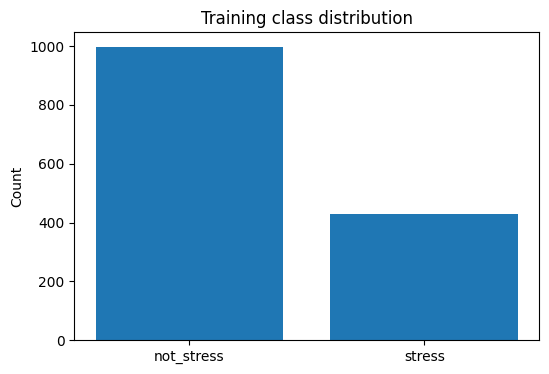

In [9]:
plt.figure(figsize=(6,4))
vals, counts = np.unique(y_train, return_counts=True)
labels = [ID2LABEL[v] for v in vals]
plt.bar(labels, counts)
plt.title("Training class distribution")
plt.ylabel("Count")
plt.show()

## Contrastive augmentations

The **main SSL + fine-tune model** uses only the `jitter + scaling` contrastive augmentation pair.

- View 1: `jitter(x)` — small Gaussian noise is added to the physiological window.
- View 2: `scaling(x)` — each channel amplitude is slightly rescaled.

Other augmentations are still defined below because they are used later only for the **augmentation ablation study**.


In [10]:
# Main SSL augmentation choice
# ------------------------------------------------------------
# IMPORTANT:
# The primary SSL+fine-tune model uses ONLY jitter + scaling.
# Other augmentations are kept for the ablation section later.
# ------------------------------------------------------------

MAIN_SSL_AUGMENTATION = "jitter+scaling"

def jitter(x, sigma=0.01):
    """Add small Gaussian noise. Preserves the overall physiological pattern."""
    return (x + np.random.normal(0, sigma, size=x.shape)).astype(np.float32)

def scaling(x, sigma=0.05):
    """Randomly rescale each channel amplitude."""
    factor = np.random.normal(1.0, sigma, size=(1, x.shape[1])).astype(np.float32)
    return (x * factor).astype(np.float32)

def random_permute(x, max_segments=4):
    T = x.shape[0]
    n_segments = np.random.randint(1, max_segments + 1)
    if n_segments == 1:
        return x.copy()
    split_points = np.random.choice(np.arange(1, T), n_segments - 1, replace=False)
    split_points.sort()
    segments = np.split(np.arange(T), split_points)
    random.shuffle(segments)
    idx = np.concatenate(segments)
    return x[idx].astype(np.float32)

def dropout_noise(x, p=0.03):
    mask = (np.random.rand(*x.shape) > p).astype(np.float32)
    return (x * mask).astype(np.float32)

def time_mask(x, max_frac=0.08):
    y = x.copy()
    T = y.shape[0]
    width = max(1, int(T * np.random.uniform(0.02, max_frac)))
    start = np.random.randint(0, max(1, T - width + 1))
    y[start:start + width] = 0.0
    return y.astype(np.float32)

def freq_mask(x, max_frac=0.20):
    """Zero a random frequency band in every channel (FFT domain)."""
    y = x.copy()
    T = y.shape[0]
    for ch in range(y.shape[1]):
        Xf = np.fft.rfft(y[:, ch])
        nf = len(Xf)
        w  = max(1, int(nf * np.random.uniform(0.05, max_frac)))
        s  = np.random.randint(0, max(1, nf - w + 1))
        Xf[s:s+w] = 0.0
        y[:, ch]  = np.fft.irfft(Xf, n=T)
    return y.astype(np.float32)

def gaussian_smooth(x, sigma_range=(1.0, 5.0)):
    """Gaussian low-pass filter per channel — simulates reduced effective sampling rate."""
    sigma = np.random.uniform(*sigma_range)
    y = np.stack(
        [gaussian_filter1d(x[:, ch], sigma=sigma) for ch in range(x.shape[1])],
        axis=1
    )
    return y.astype(np.float32)

def channel_dropout(x, p=0.25):
    """Zero entire channels independently with probability p."""
    y = x.copy()
    mask = (np.random.rand(x.shape[1]) > p).astype(np.float32)
    return (y * mask[None, :]).astype(np.float32)

# Pool used only for the ablation baseline "Composed-7"; it is NOT the main SSL method.
AUG_POOL = [
    jitter,
    scaling,
    dropout_noise,
    time_mask,
    freq_mask,
    gaussian_smooth,
    channel_dropout,
]

def compose_augment(x, n=2):
    """Apply n randomly sampled augmentations in sequence. Used only in ablation."""
    chosen = random.sample(AUG_POOL, n)
    y = x.copy()
    for f in chosen:
        y = f(y)
    return y.astype(np.float32)

def random_augment(x):
    """
    Main contrastive pair used by SSLDataset.

    This is now strictly jitter + scaling:
      - x1 = jittered view
      - x2 = scaled view

    Therefore, the main SSL+fine-tune result compares:
        jitter+scaling SSL+fine-tune vs supervised from scratch.
    """
    x = x.astype(np.float32)
    return jitter(x.copy()), scaling(x.copy())


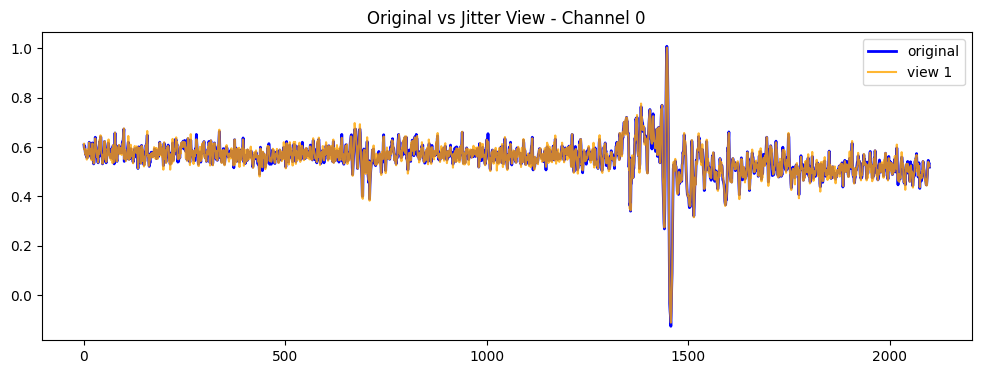

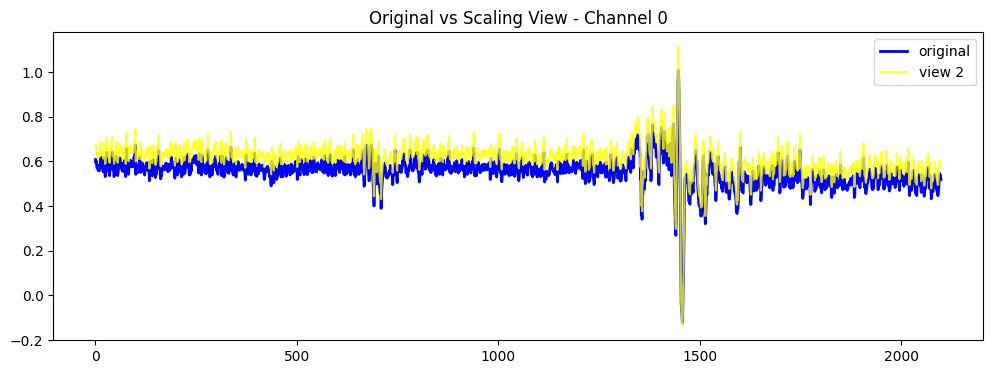

In [11]:
sample = X_train[0]
x1, x2 = random_augment(sample)

# Plot original vs view 1
plt.figure(figsize=(12, 4))
plt.plot(sample[:, 0], label="original", color="blue", linewidth=2)
plt.plot(x1[:, 0], label="view 1", color="orange", alpha=0.8)
plt.title("Original vs Jitter View - Channel 0")
plt.legend()
plt.show()

# Plot original vs view 2
plt.figure(figsize=(12, 4))
plt.plot(sample[:, 0], label="original", color="blue", linewidth=2)
plt.plot(x2[:, 0], label="view 2", color="yellow", alpha=0.8)
plt.title("Original vs Scaling View - Channel 0")
plt.legend()
plt.show()

## Datasets and models

In [12]:
class SSLDataset(Dataset):
    def __init__(self, X):
        self.X = X.astype(np.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        x1, x2 = random_augment(x)
        return torch.tensor(x1), torch.tensor(x2)

class LabeledDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx]), torch.tensor(self.y[idx])

class Encoder1D(nn.Module):
    def __init__(self, in_ch=8, emb_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(128, emb_dim)

    def forward(self, x):
        x = x.transpose(1, 2)
        h = self.net(x).squeeze(-1)
        h = self.fc(h)
        return F.normalize(h, dim=1)

class Projector(nn.Module):
    def __init__(self, emb_dim=128, proj_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, proj_dim)
        )

    def forward(self, h):
        return F.normalize(self.net(h), dim=1)

class SimCLR(nn.Module):
    def __init__(self, in_ch=8, emb_dim=128, proj_dim=128):
        super().__init__()
        self.encoder = Encoder1D(in_ch=in_ch, emb_dim=emb_dim)
        self.projector = Projector(emb_dim=emb_dim, proj_dim=proj_dim)

    def forward(self, x1, x2):
        h1 = self.encoder(x1)
        h2 = self.encoder(x2)
        z1 = self.projector(h1)
        z2 = self.projector(h2)
        return h1, h2, z1, z2

class LinearEval(nn.Module):
    def __init__(self, encoder, emb_dim=128, num_classes=3, freeze_encoder=True):
        super().__init__()
        self.encoder = encoder
        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False
        self.cls = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        h = self.encoder(x)
        return self.cls(h)

class SupervisedModel(nn.Module):
    def __init__(self, in_ch=8, emb_dim=128, num_classes=3):
        super().__init__()
        self.encoder = Encoder1D(in_ch=in_ch, emb_dim=emb_dim)
        self.cls = nn.Linear(emb_dim, num_classes)

    def forward(self, x):
        h = self.encoder(x)
        return self.cls(h)

## Loss and evaluation helpers

In [13]:
def nt_xent_loss(z1, z2, temperature=0.1):
    B = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = torch.mm(z, z.t()) / temperature

    mask = torch.eye(2 * B, device=z.device, dtype=torch.bool)
    sim = sim.masked_fill(mask, -1e9)

    targets = torch.cat([
        torch.arange(B, 2 * B, device=z.device),
        torch.arange(0, B, device=z.device)
    ], dim=0)

    return F.cross_entropy(sim, targets)

def evaluate_classifier(model, loader):
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for x, yb in loader:
            x = x.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1).cpu().numpy()
            preds.extend(pred.tolist())
            ys.extend(yb.numpy().tolist())

    labels = list(range(NUM_CLASSES))
    acc = accuracy_score(ys, preds)
    macro_f1 = f1_score(ys, preds, average="macro", labels=labels, zero_division=0)
    cm = confusion_matrix(ys, preds, labels=labels)
    report = classification_report(
        ys,
        preds,
        labels=labels,
        target_names=[ID2LABEL[i] for i in labels],
        zero_division=0
    )
    return acc, macro_f1, cm, report

def make_adamw(parameters, lr, weight_decay=WEIGHT_DECAY):
    return torch.optim.AdamW(parameters, lr=lr, weight_decay=weight_decay)

def make_warmup_cosine_scheduler(optimizer, total_epochs, warmup_epochs=WARMUP_EPOCHS, min_factor=MIN_LR_FACTOR):
    warmup_epochs = min(warmup_epochs, max(1, total_epochs - 1))

    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / float(max(1, warmup_epochs))
        progress = float(epoch - warmup_epochs + 1) / float(max(1, total_epochs - warmup_epochs))
        progress = min(1.0, max(0.0, progress))
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return min_factor + (1.0 - min_factor) * cosine

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def plot_confusion(cm, title="Confusion Matrix"):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[ID2LABEL[i] for i in range(NUM_CLASSES)],
                yticklabels=[ID2LABEL[i] for i in range(NUM_CLASSES)])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

def add_noise(X, sigma=0.05):
    return X + np.random.normal(0, sigma, size=X.shape).astype(np.float32)

def sample_fraction(X, y, frac=1.0, seed=42):
    """Stratified subsampling for low-label experiments.

    This keeps each class represented when possible, which is important for the
    binary stress/not-stress task.
    """
    if frac >= 1.0:
        return X, y

    rng = np.random.default_rng(seed)
    selected = []
    for cls in range(NUM_CLASSES):
        cls_idx = np.where(y == cls)[0]
        if len(cls_idx) == 0:
            continue
        k = max(1, int(round(len(cls_idx) * frac)))
        k = min(k, len(cls_idx))
        selected.extend(rng.choice(cls_idx, size=k, replace=False).tolist())

    selected = np.array(selected, dtype=int)
    rng.shuffle(selected)
    return X[selected], y[selected]


## Self-supervised pretraining

This is the **main SSL pretraining stage**. It uses the `SSLDataset`, whose `random_augment()` function now generates only the `jitter + scaling` positive pair.


In [14]:
train_ssl_loader = DataLoader(SSLDataset(X_train), batch_size=SSL_BATCH, shuffle=True, drop_last=True)
val_ssl_loader = DataLoader(SSLDataset(X_val), batch_size=SSL_BATCH, shuffle=False, drop_last=True)

ssl_model = SimCLR(in_ch=X_train.shape[2], emb_dim=EMB_DIM, proj_dim=PROJ_DIM).to(device)
ssl_opt = make_adamw(ssl_model.parameters(), lr=LR_SSL)
ssl_sched = make_warmup_cosine_scheduler(ssl_opt, SSL_EPOCHS)

ssl_history = {"train_loss": [], "val_loss": [], "lr": []}
best_val = float("inf")
best_ssl_path = os.path.join(OUTPUT_DIR, "ssl_best.pt")

for epoch in range(SSL_EPOCHS):
    ssl_model.train()
    tr_loss = 0.0

    for x1, x2 in tqdm(train_ssl_loader, desc=f"SSL epoch {epoch+1}/{SSL_EPOCHS}"):
        x1, x2 = x1.to(device), x2.to(device)
        _, _, z1, z2 = ssl_model(x1, x2)
        loss = nt_xent_loss(z1, z2, temperature=TEMPERATURE)

        ssl_opt.zero_grad()
        loss.backward()
        ssl_opt.step()
        tr_loss += loss.item()

    ssl_model.eval()
    va_loss = 0.0
    with torch.no_grad():
        for x1, x2 in val_ssl_loader:
            x1, x2 = x1.to(device), x2.to(device)
            _, _, z1, z2 = ssl_model(x1, x2)
            loss = nt_xent_loss(z1, z2, temperature=TEMPERATURE)
            va_loss += loss.item()

    tr_loss /= max(1, len(train_ssl_loader))
    va_loss /= max(1, len(val_ssl_loader))

    ssl_history["train_loss"].append(tr_loss)
    ssl_history["val_loss"].append(va_loss)
    ssl_history["lr"].append(ssl_sched.get_last_lr()[0])

    ssl_sched.step()

    print(f"[SSL] epoch {epoch+1:02d} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f} | lr={ssl_sched.get_last_lr()[0]:.2e}")

    if va_loss < best_val:
        best_val = va_loss
        torch.save(ssl_model.state_dict(), best_ssl_path)
        print("Saved best SSL checkpoint:", best_ssl_path)

SSL epoch 1/50:   0%|          | 0/11 [00:00<?, ?it/s]

[SSL] epoch 01 | train_loss=4.4584 | val_loss=4.9802 | lr=4.00e-04
Saved best SSL checkpoint: /content/wesad_outputs_binary/ssl_best.pt


SSL epoch 2/50:   0%|          | 0/11 [00:00<?, ?it/s]

[SSL] epoch 02 | train_loss=2.9546 | val_loss=4.7163 | lr=6.00e-04
Saved best SSL checkpoint: /content/wesad_outputs_binary/ssl_best.pt


SSL epoch 3/50:   0%|          | 0/11 [00:00<?, ?it/s]

...

[SSL] epoch 48 | train_loss=0.1499 | val_loss=3.4529 | lr=1.12e-05


SSL epoch 49/50:   0%|          | 0/11 [00:00<?, ?it/s]

[SSL] epoch 49 | train_loss=0.1488 | val_loss=3.4236 | lr=1.00e-05


SSL epoch 50/50:   0%|          | 0/11 [00:00<?, ?it/s]

[SSL] epoch 50 | train_loss=0.1632 | val_loss=3.4376 | lr=1.00e-05


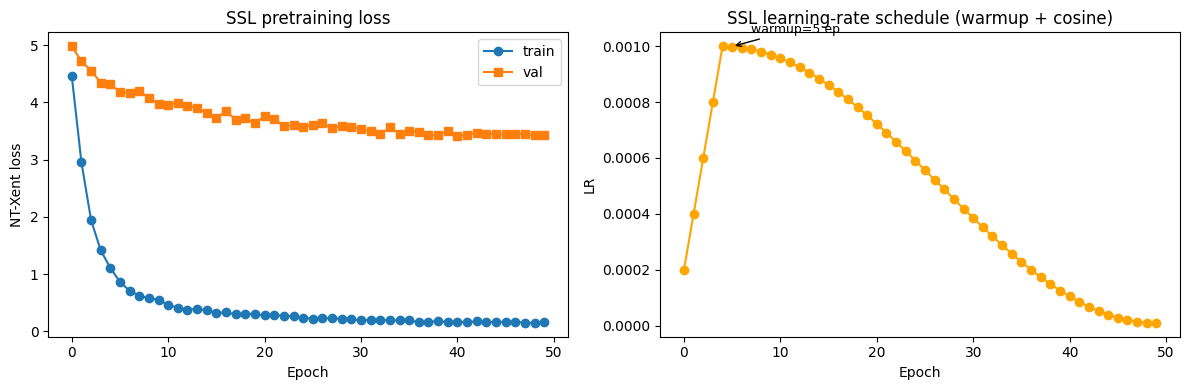

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ssl_history["train_loss"], marker="o", label="train")
axes[0].plot(ssl_history["val_loss"],   marker="s", label="val")
axes[0].set_title("SSL pretraining loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("NT-Xent loss")
axes[0].legend()
axes[1].plot(ssl_history["lr"], marker="o", color="orange")
axes[1].set_title("SSL learning-rate schedule (warmup + cosine)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("LR")
axes[1].annotate(f"warmup={WARMUP_EPOCHS} ep", xy=(WARMUP_EPOCHS, ssl_history["lr"][WARMUP_EPOCHS]),
                  xytext=(WARMUP_EPOCHS+2, ssl_history["lr"][WARMUP_EPOCHS]*1.05),
                  arrowprops=dict(arrowstyle="->"), fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ssl_training_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

## SSL fine-tuning

The encoder is first pretrained with SimCLR using the **jitter + scaling** contrastive pair.  
Then the SSL encoder is fine-tuned end-to-end using the labeled training windows.

This is the main SSL-based model compared against the fully supervised model trained from scratch.


Training class counts: {'not_stress': 997, 'stress': 428}
Cross-entropy class weights: {'not_stress': 0.7146439552307129, 'stress': 1.664719581604004}
[SSL Fine-tune] epoch 01 | loss=0.6942 | acc=0.4236 | macro_f1=0.3165 | lr=4.00e-05
[SSL Fine-tune] epoch 02 | loss=0.6826 | acc=0.5208 | macro_f1=0.4954 | lr=6.00e-05
[SSL Fine-tune] epoch 03 | loss=0.6650 | acc=0.5833 | macro_f1=0.5790 | lr=8.00e-05
[SSL Fine-tune] epoch 04 | loss=0.6435 | acc=0.5787 | macro_f1=0.5743 | lr=1.00e-04
[SSL Fine-tune] epoch 05 | loss=0.6169 | acc=0.6019 | macro_f1=0.5945 | lr=9.96e-05
[SSL Fine-tune] epoch 06 | loss=0.5848 | acc=0.7060 | macro_f1=0.6844 | lr=9.84e-05
[SSL Fine-tune] epoch 07 | loss=0.5563 | acc=0.8218 | macro_f1=0.7922 | lr=9.65e-05
[SSL Fine-tune] epoch 08 | loss=0.5323 | acc=0.8958 | macro_f1=0.8724 | lr=9.39e-05
[SSL Fine-tune] epoch 09 | loss=0.5115 | acc=0.8958 | macro_f1=0.8685 | lr=9.05e-05
[SSL Fine-tune] epoch 10 | loss=0.4945 | acc=0.8866 | macro_f1=0.8552 | lr=8.66e-05
[SSL Fine

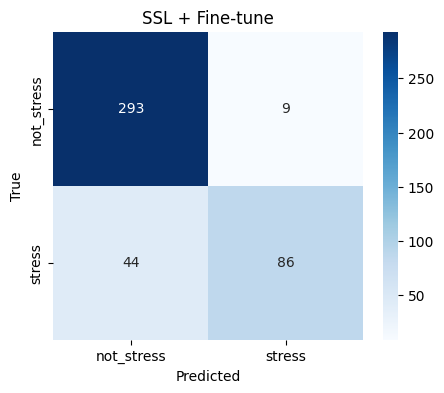

In [16]:
ssl_model_ft = SimCLR(in_ch=X_train.shape[2], emb_dim=EMB_DIM, proj_dim=PROJ_DIM).to(device)
ssl_model_ft.load_state_dict(torch.load(best_ssl_path, map_location=device))

train_loader = DataLoader(LabeledDataset(X_train, y_train), batch_size=SUP_BATCH, shuffle=True)
test_loader = DataLoader(LabeledDataset(X_test, y_test), batch_size=SUP_BATCH, shuffle=False)

# Class-weighted CE is useful for binary stress detection because
# not_stress usually has more windows than stress.
class_counts = np.bincount(y_train, minlength=NUM_CLASSES)
class_weights = class_counts.sum() / (NUM_CLASSES * np.maximum(class_counts, 1))
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print("Training class counts:", {ID2LABEL[i]: int(class_counts[i]) for i in range(NUM_CLASSES)})
print("Cross-entropy class weights:", {ID2LABEL[i]: float(class_weights[i].cpu()) for i in range(NUM_CLASSES)})

finetune_model = LinearEval(
    ssl_model_ft.encoder,
    emb_dim=EMB_DIM,
    num_classes=NUM_CLASSES,
    freeze_encoder=False
).to(device)

# Fine-tuning usually works better with a smaller learning rate than training from scratch.
ft_opt = make_adamw(finetune_model.parameters(), lr=LR_FINETUNE)
ft_sched = make_warmup_cosine_scheduler(ft_opt, FINETUNE_EPOCHS)

ft_history = {"train_loss": [], "test_acc": [], "test_f1": []}

for epoch in range(FINETUNE_EPOCHS):
    finetune_model.train()
    running = 0.0

    for x, yb in train_loader:
        x, yb = x.to(device), yb.to(device)
        logits = finetune_model(x)
        loss = criterion(logits, yb)

        ft_opt.zero_grad()
        loss.backward()
        ft_opt.step()
        running += loss.item()

    avg_loss = running / max(1, len(train_loader))
    acc, macro_f1, cm, report = evaluate_classifier(finetune_model, test_loader)

    ft_history["train_loss"].append(avg_loss)
    ft_history["test_acc"].append(acc)
    ft_history["test_f1"].append(macro_f1)

    ft_sched.step()

    print(
        f"[SSL Fine-tune] epoch {epoch+1:02d} | "
        f"loss={avg_loss:.4f} | acc={acc:.4f} | "
        f"macro_f1={macro_f1:.4f} | lr={ft_sched.get_last_lr()[0]:.2e}"
    )

ft_acc, ft_f1, ft_cm, ft_report = evaluate_classifier(finetune_model, test_loader)

print("\nFinal SSL + Fine-tune results")
print("Accuracy :", ft_acc)
print("Macro-F1 :", ft_f1)
print(ft_report)
plot_confusion(ft_cm, title="SSL + Fine-tune")


## Supervised baseline

[Supervised] epoch 01 | loss=0.6504 | acc=0.6458 | macro_f1=0.6146 | lr=4.00e-04
[Supervised] epoch 02 | loss=0.5728 | acc=0.7130 | macro_f1=0.6907 | lr=6.00e-04
[Supervised] epoch 03 | loss=0.4593 | acc=0.8542 | macro_f1=0.8306 | lr=8.00e-04
[Supervised] epoch 04 | loss=0.3685 | acc=0.9097 | macro_f1=0.8854 | lr=1.00e-03
[Supervised] epoch 05 | loss=0.3330 | acc=0.8542 | macro_f1=0.8339 | lr=9.96e-04
[Supervised] epoch 06 | loss=0.3051 | acc=0.8681 | macro_f1=0.8277 | lr=9.84e-04
[Supervised] epoch 07 | loss=0.2806 | acc=0.6759 | macro_f1=0.6498 | lr=9.65e-04
[Supervised] epoch 08 | loss=0.2290 | acc=0.8380 | macro_f1=0.8083 | lr=9.39e-04
[Supervised] epoch 09 | loss=0.1928 | acc=0.8611 | macro_f1=0.8181 | lr=9.05e-04
[Supervised] epoch 10 | loss=0.1398 | acc=0.8796 | macro_f1=0.8414 | lr=8.66e-04
[Supervised] epoch 11 | loss=0.1336 | acc=0.8056 | macro_f1=0.7423 | lr=8.21e-04
[Supervised] epoch 12 | loss=0.1613 | acc=0.8750 | macro_f1=0.8323 | lr=7.70e-04
[Supervised] epoch 13 | loss

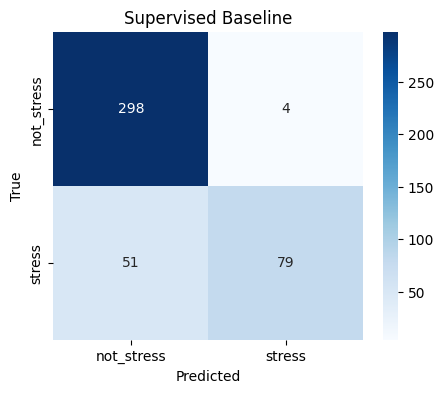

In [17]:
sup_model = SupervisedModel(in_ch=X_train.shape[2], emb_dim=EMB_DIM, num_classes=NUM_CLASSES).to(device)
sup_opt = make_adamw(sup_model.parameters(), lr=LR_SUP)
sup_sched = make_warmup_cosine_scheduler(sup_opt, SUP_EPOCHS)
# Reuse the same class-weighted criterion as SSL fine-tuning for a fair comparison.

sup_history = {"train_loss": [], "test_acc": [], "test_f1": []}

for epoch in range(SUP_EPOCHS):
    sup_model.train()
    running = 0.0

    for x, yb in train_loader:
        x, yb = x.to(device), yb.to(device)
        logits = sup_model(x)
        loss = criterion(logits, yb)

        sup_opt.zero_grad()
        loss.backward()
        sup_opt.step()
        running += loss.item()

    avg_loss = running / max(1, len(train_loader))
    acc, macro_f1, cm, report = evaluate_classifier(sup_model, test_loader)

    sup_history["train_loss"].append(avg_loss)
    sup_history["test_acc"].append(acc)
    sup_history["test_f1"].append(macro_f1)

    sup_sched.step()

    print(f"[Supervised] epoch {epoch+1:02d} | loss={avg_loss:.4f} | acc={acc:.4f} | macro_f1={macro_f1:.4f} | lr={sup_sched.get_last_lr()[0]:.2e}")

sup_acc, sup_f1, sup_cm, sup_report = evaluate_classifier(sup_model, test_loader)

print("\nFinal Supervised results")
print("Accuracy :", sup_acc)
print("Macro-F1 :", sup_f1)
print(sup_report)
plot_confusion(sup_cm, title="Supervised Baseline")

## Compare main results

,Method,Accuracy,Macro-F1
0,SSL + Fine-tune,0.8773,0.8408
1,Supervised,0.8727,0.8286


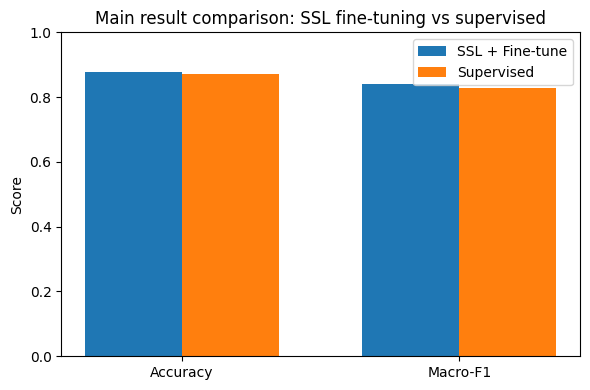

In [41]:
results_df = pd.DataFrame([
    {"Method": "SSL + Fine-tune", "Accuracy": ft_acc, "Macro-F1": ft_f1},
    {"Method": "Supervised",      "Accuracy": sup_acc, "Macro-F1": sup_f1},
])

display(results_df.round(4))

metrics = ["Accuracy", "Macro-F1"]
x = np.arange(len(metrics))
w = 0.35

ssl_values = [
    results_df.loc[results_df["Method"] == "SSL + Fine-tune", "Accuracy"].values[0],
    results_df.loc[results_df["Method"] == "SSL + Fine-tune", "Macro-F1"].values[0],
]

sup_values = [
    results_df.loc[results_df["Method"] == "Supervised", "Accuracy"].values[0],
    results_df.loc[results_df["Method"] == "Supervised", "Macro-F1"].values[0],
]

plt.figure(figsize=(6, 4))

plt.bar(x - w/2, ssl_values, width=w, label="SSL + Fine-tune")
plt.bar(x + w/2, sup_values, width=w, label="Supervised")

plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Main result comparison: SSL fine-tuning vs supervised")
plt.legend()
plt.tight_layout()
plt.show()

## Low-label study

In [19]:
fractions = [0.10, 0.25, 0.50, 1.00]
low_label_rows = []

for frac in fractions:
    X_sub, y_sub = sample_fraction(X_train, y_train, frac=frac, seed=SEED)
    train_sub_loader = DataLoader(LabeledDataset(X_sub, y_sub), batch_size=SUP_BATCH, shuffle=True)

    # SSL + Fine-tune using the jitter+scaling pretrained checkpoint
    ssl_model_tmp = SimCLR(in_ch=X_train.shape[2], emb_dim=EMB_DIM, proj_dim=PROJ_DIM).to(device)
    ssl_model_tmp.load_state_dict(torch.load(best_ssl_path, map_location=device))

    ssl_finetune = LinearEval(
        ssl_model_tmp.encoder,
        emb_dim=EMB_DIM,
        num_classes=NUM_CLASSES,
        freeze_encoder=False
    ).to(device)

    opt = make_adamw(ssl_finetune.parameters(), lr=LR_FINETUNE)
    sched = make_warmup_cosine_scheduler(opt, FINETUNE_EPOCHS)

    for epoch in range(FINETUNE_EPOCHS):
        ssl_finetune.train()
        for xb, yb in train_sub_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(ssl_finetune(xb), yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
        sched.step()

    acc, f1, _, _ = evaluate_classifier(ssl_finetune, test_loader)
    low_label_rows.append({
        "Method": "SSL + Fine-tune",
        "Label Fraction": frac,
        "Accuracy": acc,
        "Macro-F1": f1
    })

    # Supervised from scratch
    sup_tmp = SupervisedModel(in_ch=X_train.shape[2], emb_dim=EMB_DIM, num_classes=NUM_CLASSES).to(device)
    opt2 = make_adamw(sup_tmp.parameters(), lr=LR_SUP)
    sched2 = make_warmup_cosine_scheduler(opt2, SUP_EPOCHS)

    for epoch in range(SUP_EPOCHS):
        sup_tmp.train()
        for xb, yb in train_sub_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(sup_tmp(xb), yb)
            opt2.zero_grad()
            loss.backward()
            opt2.step()
        sched2.step()

    acc, f1, _, _ = evaluate_classifier(sup_tmp, test_loader)
    low_label_rows.append({
        "Method": "Supervised",
        "Label Fraction": frac,
        "Accuracy": acc,
        "Macro-F1": f1
    })

low_label_df = pd.DataFrame(low_label_rows)
display(low_label_df.round(4))


,Method,Label Fraction,Accuracy,Macro-F1
0,SSL + Fine-tune,0.10,0.6042,0.5813
1,Supervised,0.10,0.7477,0.7093
2,SSL + Fine-tune,0.25,0.7593,0.7176
3,Supervised,0.25,0.8032,0.7282
4,SSL + Fine-tune,0.50,0.8519,0.8049
5,Supervised,0.50,0.8032,0.7205
6,SSL + Fine-tune,1.00,0.8634,0.8217
7,Supervised,1.00,0.8079,0.7414


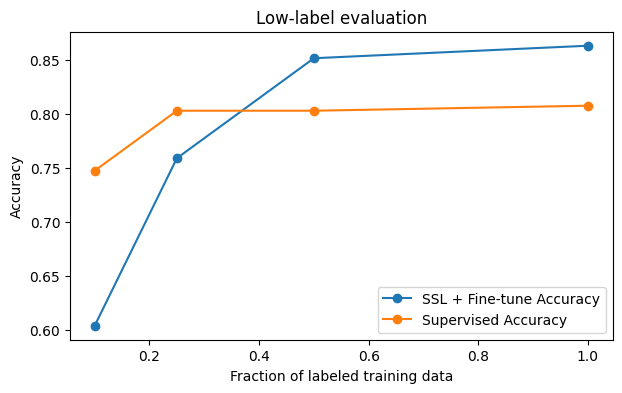

In [20]:
plt.figure(figsize=(7,4))
for method in low_label_df["Method"].unique():
    dfm = low_label_df[low_label_df["Method"] == method].sort_values("Label Fraction")
    plt.plot(dfm["Label Fraction"], dfm["Accuracy"], marker="o", label=f"{method} Accuracy")

plt.title("Low-label evaluation")
plt.xlabel("Fraction of labeled training data")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Robustness under sensor noise

In [21]:
noise_levels = [0.01, 0.03, 0.05, 0.10]
noise_rows = []

for sigma in noise_levels:
    X_noisy = add_noise(X_test, sigma=sigma)
    noisy_loader = DataLoader(LabeledDataset(X_noisy, y_test), batch_size=SUP_BATCH, shuffle=False)

    acc, f1, _, _ = evaluate_classifier(finetune_model, noisy_loader)
    noise_rows.append({
        "Method": "SSL + Fine-tune",
        "Noise Sigma": sigma,
        "Accuracy": acc,
        "Macro-F1": f1
    })

    acc, f1, _, _ = evaluate_classifier(sup_model, noisy_loader)
    noise_rows.append({
        "Method": "Supervised",
        "Noise Sigma": sigma,
        "Accuracy": acc,
        "Macro-F1": f1
    })

noise_df = pd.DataFrame(noise_rows)
display(noise_df.round(4))


,Method,Noise Sigma,Accuracy,Macro-F1
0,SSL + Fine-tune,0.01,0.8773,0.8408
1,Supervised,0.01,0.8727,0.8286
2,SSL + Fine-tune,0.03,0.8773,0.8408
3,Supervised,0.03,0.8727,0.8286
4,SSL + Fine-tune,0.05,0.8773,0.8408
5,Supervised,0.05,0.8727,0.8286
6,SSL + Fine-tune,0.10,0.8773,0.8408
7,Supervised,0.10,0.8750,0.8323


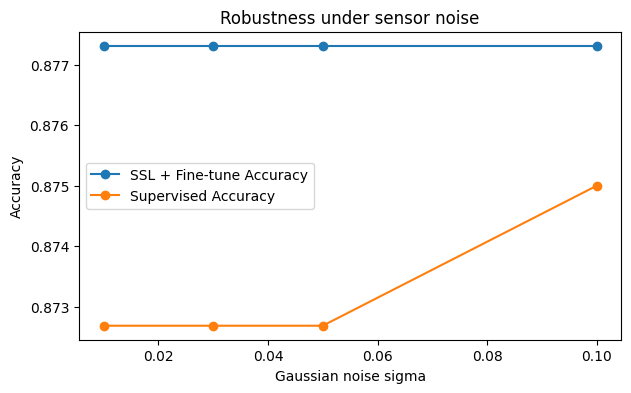

In [22]:
plt.figure(figsize=(7,4))
for method in noise_df["Method"].unique():
    dfm = noise_df[noise_df["Method"] == method].sort_values("Noise Sigma")
    plt.plot(dfm["Noise Sigma"], dfm["Accuracy"], marker="o", label=f"{method} Accuracy")

plt.title("Robustness under sensor noise")
plt.xlabel("Gaussian noise sigma")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Extended Robustness: Sensor Channel Dropout

We simulate individual sensor failures by zeroing out one channel at a time.
This models a real-world scenario where a wearable sensor malfunctions.
Both the SSL fine-tuned model and supervised model are evaluated under each single-channel dropout.


In [23]:
CHANNEL_NAMES = ['ACC_x', 'ACC_y', 'ACC_z', 'ECG', 'EDA', 'EMG', 'Resp', 'Temp']

def channel_mask(X, ch_idx):
    Xm = X.copy()
    Xm[:, :, ch_idx] = 0.0
    return Xm

channel_rows = []
for ch_idx, ch_name in enumerate(CHANNEL_NAMES):
    X_masked = channel_mask(X_test, ch_idx)
    masked_loader = DataLoader(
        LabeledDataset(X_masked, y_test),
        batch_size=SUP_BATCH,
        shuffle=False
    )

    acc, f1, _, _ = evaluate_classifier(finetune_model, masked_loader)
    channel_rows.append({
        'Method': 'SSL + Fine-tune',
        'Dropped Channel': ch_name,
        'Accuracy': acc,
        'Macro-F1': f1
    })

    acc, f1, _, _ = evaluate_classifier(sup_model, masked_loader)
    channel_rows.append({
        'Method': 'Supervised',
        'Dropped Channel': ch_name,
        'Accuracy': acc,
        'Macro-F1': f1
    })

channel_df = pd.DataFrame(channel_rows)
display(channel_df.round(4))


,Method,Dropped Channel,Accuracy,Macro-F1
0,SSL + Fine-tune,ACC_x,0.8565,0.8086
1,Supervised,ACC_x,0.7824,0.6618
2,SSL + Fine-tune,ACC_y,0.8356,0.7978
3,Supervised,ACC_y,0.7407,0.6382
4,SSL + Fine-tune,ACC_z,0.8403,0.7731
5,Supervised,ACC_z,0.8750,0.8333
6,SSL + Fine-tune,ECG,0.8704,0.8282
7,Supervised,ECG,0.7384,0.5368
8,SSL + Fine-tune,EDA,0.7847,0.7310
9,Supervised,EDA,0.8194,0.7408


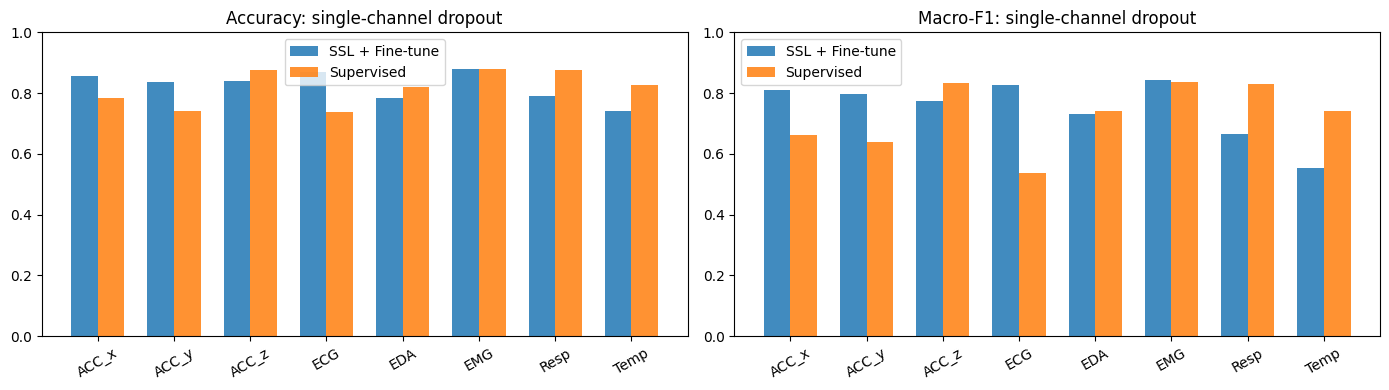

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x = np.arange(len(CHANNEL_NAMES))
w = 0.35

for ax, metric in zip(axes, ['Accuracy', 'Macro-F1']):
    ssl_vals = channel_df[channel_df['Method'] == 'SSL + Fine-tune'].sort_values('Dropped Channel')
    sup_vals = channel_df[channel_df['Method'] == 'Supervised'].sort_values('Dropped Channel')
    cnames = ssl_vals['Dropped Channel'].tolist()

    ax.bar(x - w/2, ssl_vals[metric].values, width=w, label='SSL + Fine-tune', alpha=0.85)
    ax.bar(x + w/2, sup_vals[metric].values, width=w, label='Supervised', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(cnames, rotation=30)
    ax.set_ylim(0, 1)
    ax.set_title(f'{metric}: single-channel dropout')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'channel_dropout.png'), dpi=150, bbox_inches='tight')
plt.show()


## Augmentation Strategy Ablation

The **main result above** uses `jitter+scaling` because it is the chosen SSL augmentation strategy.

This ablation study is kept separately to show how different contrastive augmentation choices affect downstream SSL fine-tuning. Each row below trains a separate SimCLR model, fine-tunes the encoder end-to-end, and reports downstream test performance.

| Pair | View 1 | View 2 |
|------|--------|--------|
| jitter+scaling  | Gaussian jitter | Amplitude scaling |
| jitter+permute  | Gaussian jitter | Temporal permutation |
| scaling+dropout | Amplitude scaling | Random point dropout |
| permute+dropout | Temporal permutation | Random point dropout |
| Composed-7 | Two random augmentations from a 7-function pool | Two random augmentations from the same pool |


In [25]:
AUG_PAIRS = {
    'jitter+scaling':  (jitter,           scaling),
    'jitter+permute':  (jitter,           random_permute),
    'scaling+dropout': (scaling,          dropout_noise),
    'permute+dropout': (random_permute,   dropout_noise),
    'Composed-7':      (compose_augment,  compose_augment),  # ablation only: 2-augmentation chain from 7-function pool
}

class SSLDatasetAug(Dataset):
    def __init__(self, X, f1, f2):
        self.X = X.astype(np.float32)
        self.f1, self.f2 = f1, f2

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        return torch.tensor(self.f1(x.copy())), torch.tensor(self.f2(x.copy()))

aug_rows = []
aug_ssl_curves = {}

for aug_name, (f1, f2) in AUG_PAIRS.items():
    print(f'\n=== Augmentation pair: {aug_name} ===')
    safe_name = aug_name.replace('+', '_')
    aloader = DataLoader(
        SSLDatasetAug(X_train, f1, f2),
        batch_size=SSL_BATCH,
        shuffle=True,
        drop_last=True
    )
    vloader = DataLoader(
        SSLDatasetAug(X_val, f1, f2),
        batch_size=SSL_BATCH,
        shuffle=False,
        drop_last=True
    )

    am = SimCLR(in_ch=X_train.shape[2], emb_dim=EMB_DIM, proj_dim=PROJ_DIM).to(device)
    ao = make_adamw(am.parameters(), lr=LR_SSL)
    asched = make_warmup_cosine_scheduler(ao, SSL_EPOCHS)
    best_av = float('inf')
    best_ap = os.path.join(OUTPUT_DIR, f'ssl_aug_{safe_name}.pt')
    aug_train_losses = []

    for ep in range(SSL_EPOCHS):
        am.train()
        tl = 0.0

        for x1, x2 in aloader:
            x1, x2 = x1.to(device), x2.to(device)
            _, _, z1, z2 = am(x1, x2)
            loss = nt_xent_loss(z1, z2, TEMPERATURE)

            ao.zero_grad()
            loss.backward()
            ao.step()
            tl += loss.item()

        am.eval()
        vl = 0.0
        with torch.no_grad():
            for x1, x2 in vloader:
                x1, x2 = x1.to(device), x2.to(device)
                _, _, z1, z2 = am(x1, x2)
                vl += nt_xent_loss(z1, z2, TEMPERATURE).item()

        tl /= max(1, len(aloader))
        vl /= max(1, len(vloader))
        aug_train_losses.append(tl)

        if vl < best_av:
            best_av = vl
            torch.save(am.state_dict(), best_ap)

        asched.step()

        if (ep + 1) % 5 == 0:
            print(
                f'  ep {ep+1:02d} | train={tl:.4f} | '
                f'val={vl:.4f} | lr={asched.get_last_lr()[0]:.2e}'
            )

    aug_ssl_curves[aug_name] = aug_train_losses

    am.load_state_dict(torch.load(best_ap, map_location=device))

    ft_eval = LinearEval(
        am.encoder,
        emb_dim=EMB_DIM,
        num_classes=NUM_CLASSES,
        freeze_encoder=False
    ).to(device)

    ft_opt_aug = make_adamw(ft_eval.parameters(), lr=LR_FINETUNE)
    ft_sched_aug = make_warmup_cosine_scheduler(ft_opt_aug, FINETUNE_EPOCHS)

    for ep in range(FINETUNE_EPOCHS):
        ft_eval.train()
        for x, yb in train_loader:
            x, yb = x.to(device), yb.to(device)
            loss = criterion(ft_eval(x), yb)

            ft_opt_aug.zero_grad()
            loss.backward()
            ft_opt_aug.step()

        ft_sched_aug.step()

    acc, f1_score_val, _, _ = evaluate_classifier(ft_eval, test_loader)
    aug_rows.append({
        'Augmentation Pair': aug_name,
        'Accuracy': acc,
        'Macro-F1': f1_score_val
    })
    print(f'  => Fine-tuned Accuracy={acc:.4f}, Macro-F1={f1_score_val:.4f}')

aug_df = pd.DataFrame(aug_rows)
display(aug_df.round(4))



=== Augmentation pair: jitter+scaling ===
  ep 05 | train=1.3221 | val=4.4827 | lr=9.99e-04
  ep 10 | train=0.5461 | val=4.2101 | lr=9.57e-04
  ep 15 | train=0.4335 | val=3.9896 | lr=8.61e-04
  ep 20 | train=0.3219 | val=3.8994 | lr=7.22e-04
  ep 25 | train=0.2851 | val=3.7345 | lr=5.57e-04
  ep 30 | train=0.2336 | val=3.7018 | lr=3.85e-04
  ep 35 | train=0.2152 | val=3.6963 | lr=2.28e-04
  ep 40 | train=0.1738 | val=3.6919 | lr=1.05e-04
  ep 45 | train=0.1782 | val=3.6751 | lr=2.92e-05
  ep 50 | train=0.1657 | val=3.6679 | lr=1.00e-05
  => Fine-tuned Accuracy=0.8588, Macro-F1=0.8134

=== Augmentation pair: jitter+permute ===
  ep 05 | train=1.1350 | val=4.6124 | lr=9.99e-04
  ep 10 | train=0.4644 | val=4.2231 | lr=9.57e-04
  ep 15 | train=0.3018 | val=3.9274 | lr=8.61e-04
  ep 20 | train=0.2341 | val=3.9709 | lr=7.22e-04
  ep 25 | train=0.1873 | val=3.8588 | lr=5.57e-04
  ep 30 | train=0.1688 | val=3.9766 | lr=3.85e-04
  ep 35 | train=0.1285 | val=3.8391 | lr=2.28e-04
  ep 40 | train

,Augmentation Pair,Accuracy,Macro-F1
0,jitter+scaling,0.8588,0.8134
1,jitter+permute,0.8981,0.8682
2,scaling+dropout,0.8727,0.8347
3,permute+dropout,0.8750,0.8363
4,Composed-7,0.7824,0.6754


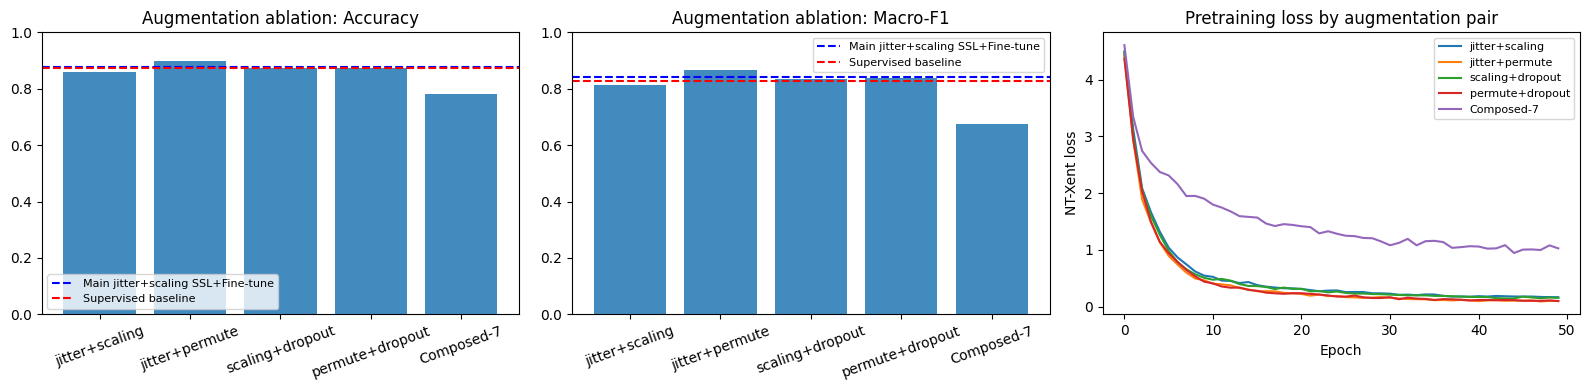

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for col, ax in zip(['Accuracy', 'Macro-F1'], axes[:2]):
    ax.bar(aug_df['Augmentation Pair'], aug_df[col], alpha=0.85)
    ax.axhline(
        ft_acc if col == 'Accuracy' else ft_f1,
        color='blue',
        linestyle='--',
        label='Main jitter+scaling SSL+Fine-tune'
    )
    ax.axhline(
        sup_acc if col == 'Accuracy' else sup_f1,
        color='red',
        linestyle='--',
        label='Supervised baseline'
    )
    ax.set_ylim(0, 1)
    ax.set_xticks(range(len(aug_df)))
    ax.set_title(f'Augmentation ablation: {col}')
    ax.set_xticklabels(aug_df['Augmentation Pair'], rotation=20)
    ax.legend(fontsize=8)

ax3 = axes[2]
for aname, losses in aug_ssl_curves.items():
    ax3.plot(losses, label=aname)
ax3.set_title('Pretraining loss by augmentation pair')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('NT-Xent loss')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'aug_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()


## Temperature Sensitivity Study

The NT-Xent temperature τ controls the sharpness of the similarity distribution.
Low τ forces hard distinctions between all negatives; high τ makes the loss more uniform.
We sweep τ ∈ {0.05, 0.10, 0.20, 0.50} and measure downstream SSL fine-tuning accuracy.


In [27]:
# Temperature sensitivity uses the main jitter+scaling SSLDataset.
temperatures = [0.05, 0.10, 0.20, 0.50]
temp_rows = []
temp_ssl_curves = {}

for tau in temperatures:
    print(f'\n=== Temperature tau={tau} ===')
    tau_tag = str(tau).replace('.', '')
    tloader = DataLoader(SSLDataset(X_train), batch_size=SSL_BATCH, shuffle=True, drop_last=True)
    vloader2 = DataLoader(SSLDataset(X_val), batch_size=SSL_BATCH, shuffle=False, drop_last=True)

    tm = SimCLR(in_ch=X_train.shape[2], emb_dim=EMB_DIM, proj_dim=PROJ_DIM).to(device)
    to_ = make_adamw(tm.parameters(), lr=LR_SSL)
    tsched = make_warmup_cosine_scheduler(to_, SSL_EPOCHS)
    best_tv = float('inf')
    best_tp = os.path.join(OUTPUT_DIR, f'ssl_tau_{tau_tag}.pt')
    tau_train_losses = []

    for ep in range(SSL_EPOCHS):
        tm.train()
        tl = 0.0

        for x1, x2 in tloader:
            x1, x2 = x1.to(device), x2.to(device)
            _, _, z1, z2 = tm(x1, x2)
            loss = nt_xent_loss(z1, z2, tau)

            to_.zero_grad()
            loss.backward()
            to_.step()
            tl += loss.item()

        tm.eval()
        vl = 0.0
        with torch.no_grad():
            for x1, x2 in vloader2:
                x1, x2 = x1.to(device), x2.to(device)
                _, _, z1, z2 = tm(x1, x2)
                vl += nt_xent_loss(z1, z2, tau).item()

        tl /= max(1, len(tloader))
        vl /= max(1, len(vloader2))
        tau_train_losses.append(tl)

        if vl < best_tv:
            best_tv = vl
            torch.save(tm.state_dict(), best_tp)

        tsched.step()

        if (ep + 1) % 5 == 0:
            print(
                f'  ep {ep+1:02d} | train={tl:.4f} | '
                f'val={vl:.4f} | lr={tsched.get_last_lr()[0]:.2e}'
            )

    temp_ssl_curves[str(tau)] = tau_train_losses

    tm.load_state_dict(torch.load(best_tp, map_location=device))
    ft_tau = LinearEval(
        tm.encoder,
        emb_dim=EMB_DIM,
        num_classes=NUM_CLASSES,
        freeze_encoder=False
    ).to(device)

    ft_tau_opt = make_adamw(ft_tau.parameters(), lr=LR_FINETUNE)
    ft_tau_sched = make_warmup_cosine_scheduler(ft_tau_opt, FINETUNE_EPOCHS)

    for ep in range(FINETUNE_EPOCHS):
        ft_tau.train()
        for x, yb in train_loader:
            x, yb = x.to(device), yb.to(device)
            loss = criterion(ft_tau(x), yb)

            ft_tau_opt.zero_grad()
            loss.backward()
            ft_tau_opt.step()

        ft_tau_sched.step()

    acc, f1_tau, _, _ = evaluate_classifier(ft_tau, test_loader)
    temp_rows.append({
        'Temperature (tau)': tau,
        'Accuracy': acc,
        'Macro-F1': f1_tau
    })
    print(f'  => Fine-tuned Accuracy={acc:.4f}, Macro-F1={f1_tau:.4f}')

temp_df = pd.DataFrame(temp_rows)
display(temp_df.round(4))



=== Temperature tau=0.05 ===
  ep 05 | train=0.6619 | val=3.9920 | lr=9.99e-04
  ep 10 | train=0.2208 | val=3.1968 | lr=9.57e-04
  ep 15 | train=0.1290 | val=3.2558 | lr=8.61e-04
  ep 20 | train=0.1327 | val=3.4386 | lr=7.22e-04
  ep 25 | train=0.0828 | val=3.1159 | lr=5.57e-04
  ep 30 | train=0.0655 | val=3.0914 | lr=3.85e-04
  ep 35 | train=0.0522 | val=3.0478 | lr=2.28e-04
  ep 40 | train=0.0418 | val=3.0115 | lr=1.05e-04
  ep 45 | train=0.0373 | val=2.9219 | lr=2.92e-05
  ep 50 | train=0.0385 | val=2.9493 | lr=1.00e-05
  => Fine-tuned Accuracy=0.8819, Macro-F1=0.8476

=== Temperature tau=0.1 ===
  ep 05 | train=1.3611 | val=4.3189 | lr=9.99e-04
  ep 10 | train=0.5550 | val=3.9600 | lr=9.57e-04
  ep 15 | train=0.3913 | val=3.8500 | lr=8.61e-04
  ep 20 | train=0.2961 | val=3.7333 | lr=7.22e-04
  ep 25 | train=0.2716 | val=3.6757 | lr=5.57e-04
  ep 30 | train=0.2265 | val=3.5905 | lr=3.85e-04
  ep 35 | train=0.1890 | val=3.5549 | lr=2.28e-04
  ep 40 | train=0.1759 | val=3.5410 | lr=1

,Temperature (tau),Accuracy,Macro-F1
0,0.05,0.8819,0.8476
1,0.10,0.8866,0.8552
2,0.20,0.8218,0.7712
3,0.50,0.8565,0.8098


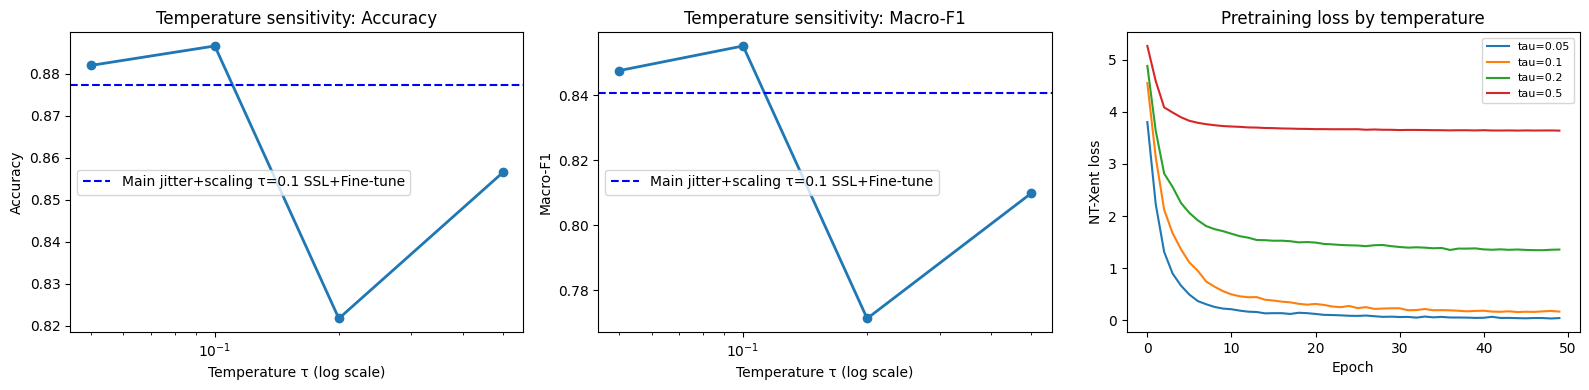

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes[:2], ['Accuracy', 'Macro-F1']):
    ax.plot(temp_df['Temperature (tau)'], temp_df[col], marker='o', linewidth=2)
    ax.set_xscale('log')
    ax.set_xlabel('Temperature τ (log scale)')
    ax.set_ylabel(col)
    ax.set_title(f'Temperature sensitivity: {col}')
    ax.axhline(
        ft_acc if col == 'Accuracy' else ft_f1,
        color='blue',
        linestyle='--',
        label='Main jitter+scaling τ=0.1 SSL+Fine-tune'
    )
    ax.legend()

ax3 = axes[2]
for tau_s, losses in temp_ssl_curves.items():
    ax3.plot(losses, label=f'tau={tau_s}')
ax3.set_title('Pretraining loss by temperature')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('NT-Xent loss')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'temperature_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()


## Representation Quality: t-SNE Visualisation

Embeddings from three encoders are projected to 2D with t-SNE:
- **Random** — baseline with no training
- **SSL fine-tuned** — SimCLR-pretrained encoder after supervised fine-tuning
- **Supervised** — end-to-end cross-entropy training from scratch

Better class separation indicates more discriminative representations.


In [29]:
from sklearn.manifold import TSNE

def extract_embeddings(encoder, X, batch_size=256):
    encoder.eval()
    embs = []
    loader = DataLoader(
        LabeledDataset(X, np.zeros(len(X), dtype=np.int64)),
        batch_size=batch_size,
        shuffle=False
    )

    with torch.no_grad():
        for xb, _ in loader:
            embs.append(encoder(xb.to(device)).cpu().numpy())

    return np.concatenate(embs, axis=0)

random_enc = Encoder1D(in_ch=X_test.shape[2], emb_dim=EMB_DIM).to(device)

rand_emb = extract_embeddings(random_enc, X_test)
ft_emb   = extract_embeddings(finetune_model.encoder, X_test)
sup_emb  = extract_embeddings(sup_model.encoder, X_test)

N_VIZ = min(800, len(X_test))
rng_viz = np.random.default_rng(SEED)
idx_viz = rng_viz.choice(len(X_test), N_VIZ, replace=False)
y_viz = y_test[idx_viz]

import sklearn
_sk_ver = tuple(int(v) for v in sklearn.__version__.split('.')[:2])
_tsne_kw = {'max_iter': 1000} if _sk_ver >= (1, 2) else {'n_iter': 1000}

tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, **_tsne_kw)
rand_2d = tsne.fit_transform(rand_emb[idx_viz])
ft_2d   = tsne.fit_transform(ft_emb[idx_viz])
sup_2d  = tsne.fit_transform(sup_emb[idx_viz])

print('t-SNE projections computed.')


t-SNE projections computed.


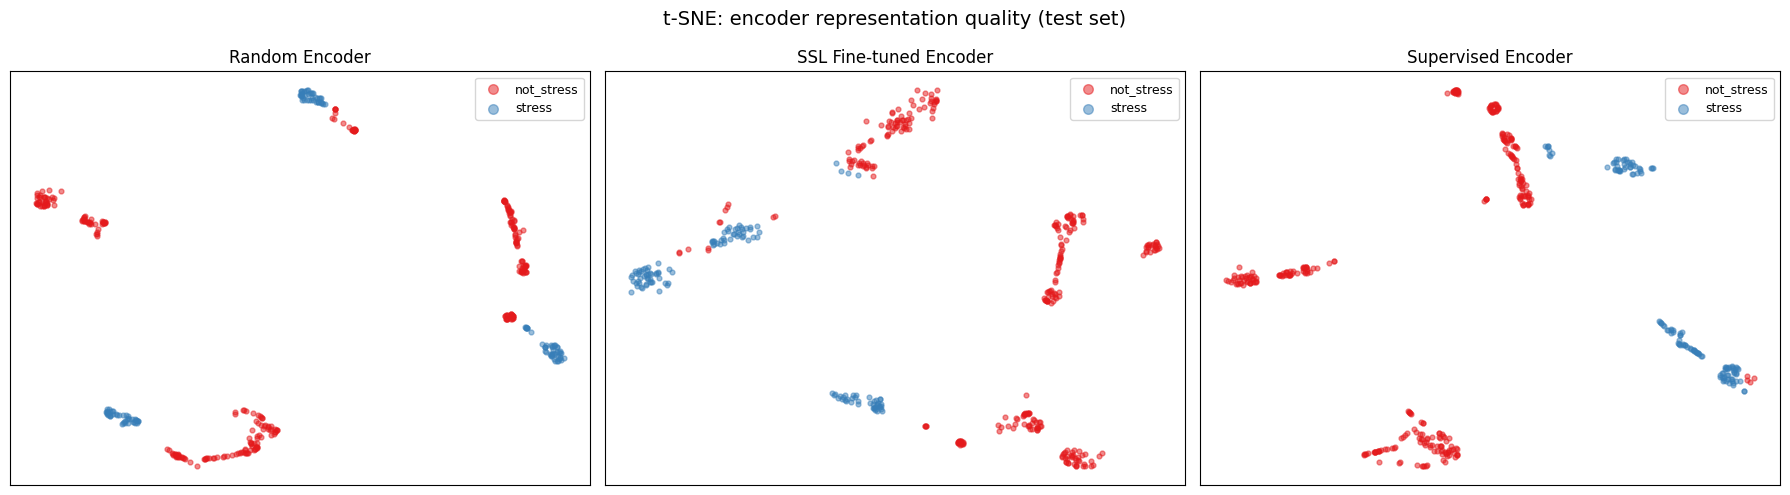

In [30]:
palette = sns.color_palette('Set1', NUM_CLASSES)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, emb2d, title in zip(
    axes,
    [rand_2d, ft_2d, sup_2d],
    ['Random Encoder', 'SSL Fine-tuned Encoder', 'Supervised Encoder']
):
    for cls_idx in range(NUM_CLASSES):
        mask = y_viz == cls_idx
        ax.scatter(
            emb2d[mask, 0],
            emb2d[mask, 1],
            label=ID2LABEL[cls_idx],
            alpha=0.5,
            s=12,
            color=palette[cls_idx]
        )

    ax.set_title(title, fontsize=12)
    ax.legend(markerscale=2, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('t-SNE: encoder representation quality (test set)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tsne_encoders.png'), dpi=150, bbox_inches='tight')
plt.show()


## Comprehensive Results Summary

All experimental results consolidated into a single table for paper reporting.

In [31]:
summary_rows = [
    {
        'Experiment': 'Main',
        'Condition': 'SSL + Fine-tune',
        'Accuracy': ft_acc,
        'Macro-F1': ft_f1
    },
    {
        'Experiment': 'Main',
        'Condition': 'Supervised (scratch)',
        'Accuracy': sup_acc,
        'Macro-F1': sup_f1
    },
]

for _, row in low_label_df.iterrows():
    summary_rows.append({
        'Experiment': f"Low-label {int(row['Label Fraction']*100)}%",
        'Condition': row['Method'],
        'Accuracy': row['Accuracy'],
        'Macro-F1': row['Macro-F1'],
    })

for _, row in noise_df.iterrows():
    summary_rows.append({
        'Experiment': f"Noise sigma={row['Noise Sigma']}",
        'Condition': row['Method'],
        'Accuracy': row['Accuracy'],
        'Macro-F1': row['Macro-F1'],
    })

for _, row in channel_df.iterrows():
    summary_rows.append({
        'Experiment': 'Channel dropout',
        'Condition': f"{row['Method']} drop={row['Dropped Channel']}",
        'Accuracy': row['Accuracy'],
        'Macro-F1': row['Macro-F1'],
    })

for _, row in aug_df.iterrows():
    summary_rows.append({
        'Experiment': 'Aug ablation',
        'Condition': row['Augmentation Pair'],
        'Accuracy': row['Accuracy'],
        'Macro-F1': row['Macro-F1'],
    })

for _, row in temp_df.iterrows():
    summary_rows.append({
        'Experiment': 'Temperature',
        'Condition': f"tau={row['Temperature (tau)']}",
        'Accuracy': row['Accuracy'],
        'Macro-F1': row['Macro-F1'],
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(4))
# Saved in the HRV section after wrist results are appended.


,Experiment,Condition,Accuracy,Macro-F1
0,Main,SSL + Fine-tune,0.8773,0.8408
1,Main,Supervised (scratch),0.8727,0.8286
2,Low-label 10%,SSL + Fine-tune,0.6042,0.5813
3,Low-label 10%,Supervised,0.7477,0.7093
4,Low-label 25%,SSL + Fine-tune,0.7593,0.7176
5,Low-label 25%,Supervised,0.8032,0.7282
6,Low-label 50%,SSL + Fine-tune,0.8519,0.8049
7,Low-label 50%,Supervised,0.8032,0.7205
8,Low-label 100%,SSL + Fine-tune,0.8634,0.8217
9,Low-label 100%,Supervised,0.8079,0.7414


## Wrist Signal Modality Experiment

The WESAD wrist device (Empatica E4) records four signal types at different rates:

| Channel | Rate |
|---------|------|
| ACC (3-axis) | 32 Hz |
| BVP | 64 Hz |
| EDA | 4 Hz |
| TEMP | 4 Hz |

All channels are resampled to 32 Hz, the ACC rate, using `scipy.signal.resample`.
This gives 6-channel windows of 960 samples at 30 seconds.
The same SimCLR + fine-tuning pipeline is applied and results are compared against chest.


In [32]:
from scipy.signal import resample as scipy_resample

WRIST_TARGET_FS = 32        # Hz — target rate for all wrist channels
WRIST_WIN  = 30 * WRIST_TARGET_FS   # 960 samples per window
WRIST_STEP = 15 * WRIST_TARGET_FS   # 480-sample stride (50 % overlap)
WRIST_IN_CH = 6             # ACC(3) + BVP + EDA + TEMP

def load_subject_wrist_pkl(pkl_path):
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    wrist = data['signal']['wrist']
    y_chest = np.asarray(data['label']).reshape(-1)   # 700 Hz

    acc  = np.asarray(wrist['ACC']).astype(np.float32)          # (N, 3) @ 32 Hz
    bvp  = np.asarray(wrist['BVP']).reshape(-1).astype(np.float32)   # @ 64 Hz
    eda  = np.asarray(wrist['EDA']).reshape(-1).astype(np.float32)   # @  4 Hz
    temp = np.asarray(wrist['TEMP']).reshape(-1).astype(np.float32)  # @  4 Hz

    N = len(acc)
    bvp_r  = scipy_resample(bvp,  N).reshape(-1, 1).astype(np.float32)
    eda_r  = scipy_resample(eda,  N).reshape(-1, 1).astype(np.float32)
    temp_r = scipy_resample(temp, N).reshape(-1, 1).astype(np.float32)

    x = np.concatenate([acc, bvp_r, eda_r, temp_r], axis=1)  # (N, 6)

    # Align chest label (700 Hz) to wrist ACC length (32 Hz)
    y_idx = np.round(np.linspace(0, len(y_chest) - 1, N)).astype(int)
    y = y_chest[y_idx]
    return x, y

# ── Load and window wrist signals ──────────────────────────────────────────
X_wrist_all, y_wrist_all, groups_wrist = [], [], []

for pkl_path in pkl_files:
    sid = os.path.basename(os.path.dirname(pkl_path))
    try:
        xw, yw_raw = load_subject_wrist_pkl(pkl_path)
        Xww, yww = make_windows(xw, yw_raw, WRIST_WIN, WRIST_STEP, LABEL_MAP, purity=PURITY)
        if len(Xww) == 0:
            print(f'Skipping {sid}: no valid wrist windows'); continue
        X_wrist_all.append(Xww)
        y_wrist_all.append(yww)
        groups_wrist.extend([sid] * len(yww))
        print(f'{sid}: {len(yww)} wrist windows')
    except Exception as exc:
        print(f'Skipping {sid} wrist: {exc}')

X_wrist = np.concatenate(X_wrist_all, axis=0)
y_wrist = np.concatenate(y_wrist_all, axis=0)
groups_wrist = np.array(groups_wrist)
print(f'\nWrist: X={X_wrist.shape}  y={y_wrist.shape}')
print('Class distribution:', Counter(y_wrist))

S10: 148 wrist windows
S11: 144 wrist windows
S13: 143 wrist windows
S14: 144 wrist windows
S15: 143 wrist windows
S16: 143 wrist windows
S17: 149 wrist windows
S2: 135 wrist windows
S3: 138 wrist windows
S4: 141 wrist windows
S5: 144 wrist windows
S6: 143 wrist windows
S7: 141 wrist windows
S8: 142 wrist windows
S9: 142 wrist windows

Wrist: X=(2140, 960, 6)  y=(2140,)
Class distribution: Counter({np.int64(0): 1498, np.int64(1): 642})


In [33]:
gss_w = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
tr_w, te_w = next(gss_w.split(X_wrist, y_wrist, groups=groups_wrist))
Xw_tr_full, yw_tr_full, gw_tr = X_wrist[tr_w], y_wrist[tr_w], groups_wrist[tr_w]
Xw_te, yw_te = X_wrist[te_w], y_wrist[te_w]

gss_w2 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
trw_idx, vaw_idx = next(gss_w2.split(Xw_tr_full, yw_tr_full, groups=gw_tr))
Xw_tr, yw_tr = Xw_tr_full[trw_idx], yw_tr_full[trw_idx]
Xw_va, yw_va = Xw_tr_full[vaw_idx], yw_tr_full[vaw_idx]

Xw_tr, Xw_va, Xw_te = standardize_train_val_test(Xw_tr, Xw_va, Xw_te)
print('Wrist train:', Xw_tr.shape, ' val:', Xw_va.shape, ' test:', Xw_te.shape)

Wrist train: (1425, 960, 6)  val: (283, 960, 6)  test: (432, 960, 6)


[Wrist SSL] epoch 01 | train=4.2702 | val=4.8614 | lr=4.00e-04
[Wrist SSL] epoch 02 | train=2.7458 | val=4.0947 | lr=6.00e-04
[Wrist SSL] epoch 03 | train=1.5764 | val=4.0019 | lr=8.00e-04
[Wrist SSL] epoch 04 | train=1.1160 | val=3.7154 | lr=1.00e-03
[Wrist SSL] epoch 05 | train=0.9215 | val=3.4473 | lr=9.99e-04
[Wrist SSL] epoch 06 | train=0.7403 | val=3.3718 | lr=9.95e-04
[Wrist SSL] epoch 07 | train=0.6799 | val=3.1683 | lr=9.89e-04
[Wrist SSL] epoch 08 | train=0.6180 | val=3.1055 | lr=9.81e-04
[Wrist SSL] epoch 09 | train=0.5441 | val=3.0122 | lr=9.70e-04
[Wrist SSL] epoch 10 | train=0.5061 | val=3.0184 | lr=9.57e-04
[Wrist SSL] epoch 11 | train=0.4485 | val=2.9662 | lr=9.42e-04
[Wrist SSL] epoch 12 | train=0.4432 | val=2.8986 | lr=9.25e-04
[Wrist SSL] epoch 13 | train=0.4354 | val=2.8498 | lr=9.05e-04
[Wrist SSL] epoch 14 | train=0.4099 | val=2.8599 | lr=8.84e-04
[Wrist SSL] epoch 15 | train=0.3642 | val=2.8161 | lr=8.61e-04
[Wrist SSL] epoch 16 | train=0.3807 | val=2.8361 | lr=8

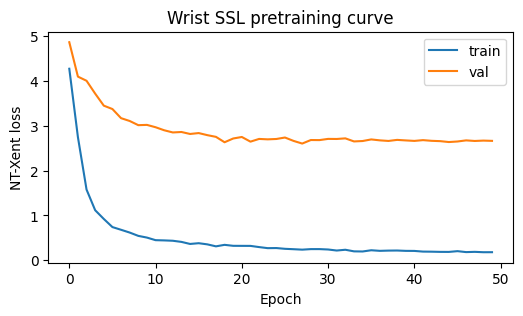

In [34]:
# Wrist SSL also uses the main jitter+scaling SSLDataset.
wrist_ssl_loader     = DataLoader(SSLDataset(Xw_tr), batch_size=SSL_BATCH, shuffle=True,  drop_last=True)
wrist_val_ssl_loader = DataLoader(SSLDataset(Xw_va), batch_size=SSL_BATCH, shuffle=False, drop_last=True)

wrist_ssl_model = SimCLR(in_ch=WRIST_IN_CH, emb_dim=EMB_DIM, proj_dim=PROJ_DIM).to(device)
wrist_ssl_opt   = make_adamw(wrist_ssl_model.parameters(), lr=LR_SSL)
wrist_ssl_sched = make_warmup_cosine_scheduler(wrist_ssl_opt, SSL_EPOCHS)
best_wrist_val  = float('inf')
best_wrist_path = os.path.join(OUTPUT_DIR, 'wrist_ssl_best.pt')
wrist_ssl_history = {'train_loss': [], 'val_loss': []}

for epoch in range(SSL_EPOCHS):
    wrist_ssl_model.train(); tr_loss = 0.0
    for x1, x2 in wrist_ssl_loader:
        x1, x2 = x1.to(device), x2.to(device)
        _, _, z1, z2 = wrist_ssl_model(x1, x2)
        loss = nt_xent_loss(z1, z2, TEMPERATURE)
        wrist_ssl_opt.zero_grad(); loss.backward(); wrist_ssl_opt.step()
        tr_loss += loss.item()
    wrist_ssl_model.eval(); va_loss = 0.0
    with torch.no_grad():
        for x1, x2 in wrist_val_ssl_loader:
            x1, x2 = x1.to(device), x2.to(device)
            _, _, z1, z2 = wrist_ssl_model(x1, x2)
            va_loss += nt_xent_loss(z1, z2, TEMPERATURE).item()
    tr_loss /= max(1, len(wrist_ssl_loader))
    va_loss /= max(1, len(wrist_val_ssl_loader))
    wrist_ssl_history['train_loss'].append(tr_loss)
    wrist_ssl_history['val_loss'].append(va_loss)
    wrist_ssl_sched.step()
    print(f'[Wrist SSL] epoch {epoch+1:02d} | train={tr_loss:.4f} | val={va_loss:.4f} | lr={wrist_ssl_sched.get_last_lr()[0]:.2e}')
    if va_loss < best_wrist_val:
        best_wrist_val = va_loss
        torch.save(wrist_ssl_model.state_dict(), best_wrist_path)

plt.figure(figsize=(6, 3))
plt.plot(wrist_ssl_history['train_loss'], label='train')
plt.plot(wrist_ssl_history['val_loss'],   label='val')
plt.title('Wrist SSL pretraining curve')
plt.xlabel('Epoch'); plt.ylabel('NT-Xent loss'); plt.legend(); plt.show()

Wrist SSL+Fine-tune: acc=0.9306  macro-F1=0.9219
              precision    recall  f1-score   support

  not_stress       1.00      0.90      0.95       302
      stress       0.82      0.99      0.90       130

    accuracy                           0.93       432
   macro avg       0.91      0.95      0.92       432
weighted avg       0.94      0.93      0.93       432



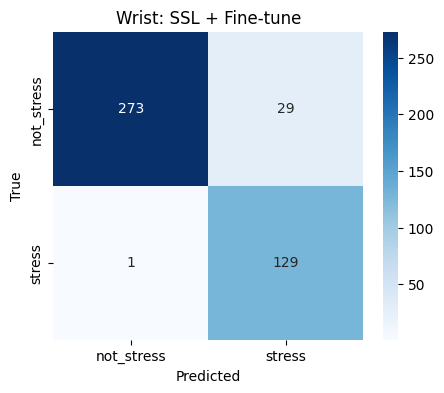

Wrist Supervised: acc=0.7963  macro-F1=0.7879
              precision    recall  f1-score   support

  not_stress       1.00      0.71      0.83       302
      stress       0.60      0.99      0.75       130

    accuracy                           0.80       432
   macro avg       0.80      0.85      0.79       432
weighted avg       0.88      0.80      0.80       432



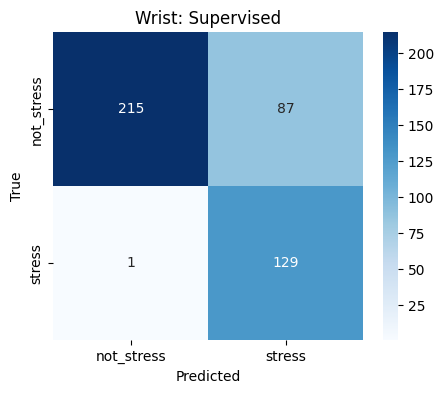

In [35]:
wrist_tr_loader = DataLoader(LabeledDataset(Xw_tr, yw_tr), batch_size=SUP_BATCH, shuffle=True)
wrist_te_loader = DataLoader(LabeledDataset(Xw_te, yw_te), batch_size=SUP_BATCH, shuffle=False)

# SSL + Fine-tune for wrist signals
wrist_ssl_ft = SimCLR(in_ch=WRIST_IN_CH, emb_dim=EMB_DIM, proj_dim=PROJ_DIM).to(device)
wrist_ssl_ft.load_state_dict(torch.load(best_wrist_path, map_location=device))

w_ft = LinearEval(
    wrist_ssl_ft.encoder,
    emb_dim=EMB_DIM,
    num_classes=NUM_CLASSES,
    freeze_encoder=False
).to(device)

w_ft_opt = make_adamw(w_ft.parameters(), lr=LR_FINETUNE)
w_ft_sched = make_warmup_cosine_scheduler(w_ft_opt, FINETUNE_EPOCHS)

for ep in range(FINETUNE_EPOCHS):
    w_ft.train()
    for x, yb in wrist_tr_loader:
        x, yb = x.to(device), yb.to(device)
        loss = criterion(w_ft(x), yb)

        w_ft_opt.zero_grad()
        loss.backward()
        w_ft_opt.step()

    w_ft_sched.step()

w_ft_acc, w_ft_f1, w_ft_cm, w_ft_report = evaluate_classifier(w_ft, wrist_te_loader)
print(f'Wrist SSL+Fine-tune: acc={w_ft_acc:.4f}  macro-F1={w_ft_f1:.4f}')
print(w_ft_report)
plot_confusion(w_ft_cm, title='Wrist: SSL + Fine-tune')

# Supervised baseline for wrist signals
w_sup = SupervisedModel(in_ch=WRIST_IN_CH, emb_dim=EMB_DIM, num_classes=NUM_CLASSES).to(device)
w_sup_opt = make_adamw(w_sup.parameters(), lr=LR_SUP)
w_sup_sched = make_warmup_cosine_scheduler(w_sup_opt, SUP_EPOCHS)

for ep in range(SUP_EPOCHS):
    w_sup.train()
    for x, yb in wrist_tr_loader:
        x, yb = x.to(device), yb.to(device)
        loss = criterion(w_sup(x), yb)

        w_sup_opt.zero_grad()
        loss.backward()
        w_sup_opt.step()

    w_sup_sched.step()

w_sup_acc, w_sup_f1, w_sup_cm, w_sup_report = evaluate_classifier(w_sup, wrist_te_loader)
print(f'Wrist Supervised: acc={w_sup_acc:.4f}  macro-F1={w_sup_f1:.4f}')
print(w_sup_report)
plot_confusion(w_sup_cm, title='Wrist: Supervised')


,Modality,Method,Accuracy,Macro-F1
0,Chest,SSL + Fine-tune,0.8773,0.8408
1,Chest,Supervised,0.8727,0.8286
2,Wrist,SSL + Fine-tune,0.9306,0.9219
3,Wrist,Supervised,0.7963,0.7879


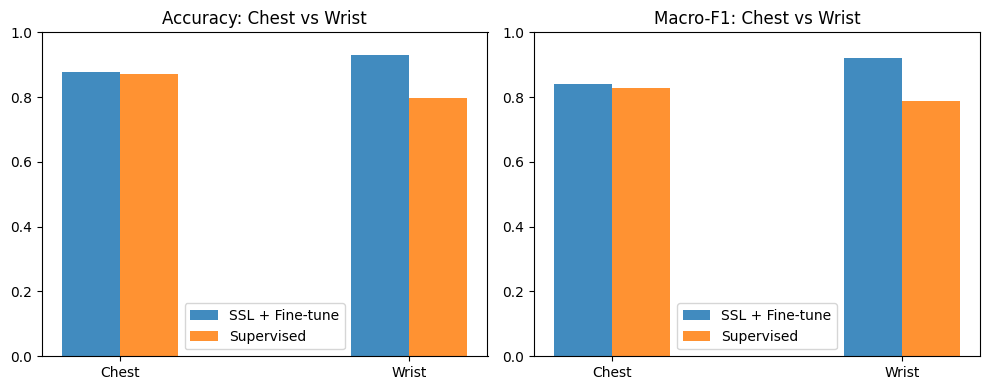

In [36]:
modality_df = pd.DataFrame([
    {'Modality': 'Chest', 'Method': 'SSL + Fine-tune', 'Accuracy': ft_acc,    'Macro-F1': ft_f1},
    {'Modality': 'Chest', 'Method': 'Supervised',      'Accuracy': sup_acc,   'Macro-F1': sup_f1},
    {'Modality': 'Wrist', 'Method': 'SSL + Fine-tune', 'Accuracy': w_ft_acc,  'Macro-F1': w_ft_f1},
    {'Modality': 'Wrist', 'Method': 'Supervised',      'Accuracy': w_sup_acc, 'Macro-F1': w_sup_f1},
])

display(modality_df.round(4))
modality_df.to_csv(os.path.join(OUTPUT_DIR, 'chest_vs_wrist.csv'), index=False)

x_pos = np.arange(2)
w_bar = 0.2

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ['Accuracy', 'Macro-F1']):
    for i, method in enumerate(['SSL + Fine-tune', 'Supervised']):
        vals = modality_df[modality_df['Method'] == method][metric].values
        ax.bar(x_pos + i * w_bar, vals, width=w_bar, label=method, alpha=0.85)

    ax.set_xticks(x_pos + w_bar / 2)
    ax.set_xticklabels(['Chest', 'Wrist'])
    ax.set_ylim(0, 1)
    ax.set_title(f'{metric}: Chest vs Wrist')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'chest_vs_wrist.png'), dpi=150, bbox_inches='tight')
plt.show()

# Extend the comprehensive summary with wrist results.
for _, row in modality_df[modality_df["Modality"] == "Wrist"].iterrows():
    summary_rows.append({
        "Experiment": "Wrist modality",
        "Condition": row["Method"],
        "Accuracy": row["Accuracy"],
        "Macro-F1": row["Macro-F1"],
    })

summary_df = pd.DataFrame(summary_rows)
# comprehensive_summary.csv will be saved after HRV results are appended.


## Traditional ML Baseline: HRV Features + Random Forest

To contextualise our deep SSL approach we build a hand-crafted feature baseline using
Heart Rate Variability (HRV) metrics extracted from the chest ECG channel.
The pipeline mirrors established clinical practice: detect R-peaks with NeuroKit2 on the
full 700 Hz signal, then compute time-domain (SDNN, RMSSD, pNN50), frequency-domain
(LF, HF, LF/HF ratio) and nonlinear HRV metrics per 2-minute sliding window.
A Random Forest classifier is then trained on these features.

**Methodological note:** we apply the same subject-level `GroupShuffleSplit` used
throughout this notebook (test subjects never seen during training), giving honest,
comparable numbers. Published baselines that use random window-level splits suffer from
subject leakage and report inflated accuracy — we avoid that here.

In [37]:
try:
    import neurokit2 as nk
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neurokit2"])
    import neurokit2 as nk

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

HRV_WIN_SEC   = 120              # 2-min windows — minimum for spectral HRV (LF/HF)
HRV_STEP_SEC  = 60               # 50 % overlap
ECG_CH_IDX    = 3                # ECG is channel 3 in the 8-channel chest array
HRV_WIN_SAMP  = HRV_WIN_SEC  * ORIG_FS   # samples at 700 Hz
HRV_STEP_SAMP = HRV_STEP_SEC * ORIG_FS


def extract_hrv_windows(pkl_path):
    """HRV features per 2-min window for one subject (700 Hz ECG, same label filter)."""
    x_full, y_full = load_subject_pkl(pkl_path)          # (N, 8) at 700 Hz
    ecg   = x_full[:, ECG_CH_IDX].flatten()
    label = y_full

    try:
        cleaned      = nk.ecg_clean(ecg, sampling_rate=ORIG_FS)
        _, rpk_dict  = nk.ecg_peaks(cleaned, sampling_rate=ORIG_FS)
        rpeaks       = rpk_dict["ECG_R_Peaks"]
    except Exception as e:
        print(f"  R-peak detection failed: {e}")
        return pd.DataFrame()

    rows = []
    for start in range(0, len(ecg) - HRV_WIN_SAMP, HRV_STEP_SAMP):
        end = start + HRV_WIN_SAMP
        pkw = rpeaks[(rpeaks >= start) & (rpeaks < end)] - start
        if len(pkw) < 4:
            continue

        # Same purity filter as deep-learning pipeline
        seg_lbl = label[start:end]
        vals, cnts = np.unique(seg_lbl, return_counts=True)
        maj = vals[np.argmax(cnts)]
        if maj not in LABEL_MAP or cnts.max() / len(seg_lbl) < PURITY:
            continue

        peaks_bool = pd.DataFrame({"ECG_R_Peaks": np.zeros(HRV_WIN_SAMP, dtype=bool)})
        peaks_bool.loc[pkw, "ECG_R_Peaks"] = True
        try:
            hrv_result = nk.hrv(peaks_bool, sampling_rate=ORIG_FS, show=False)
            row = hrv_result.iloc[0].to_dict()
            row["Label"] = LABEL_MAP[maj]
            rows.append(row)
        except Exception:
            continue

    return pd.DataFrame(rows)


# Extract HRV for all subjects
hrv_dfs, hrv_groups_list = [], []
for pkl_path in pkl_files:
    sid = os.path.basename(os.path.dirname(pkl_path))
    print(f"Processing {sid}...", end=" ", flush=True)
    df_sid = extract_hrv_windows(pkl_path)
    if df_sid.empty:
        print("skipped")
        continue
    hrv_dfs.append(df_sid)
    hrv_groups_list.extend([sid] * len(df_sid))
    print(f"{len(df_sid)} windows")

hrv_all_df     = pd.concat(hrv_dfs, ignore_index=True)
hrv_groups_arr = np.array(hrv_groups_list)

# Drop columns with >20 % NaN; impute remainder with column median
y_hrv = hrv_all_df["Label"].values.astype(np.int64)
X_hrv = hrv_all_df.drop(columns=["Label"])
nan_frac     = X_hrv.isna().mean()
X_hrv        = X_hrv.drop(columns=nan_frac[nan_frac > 0.20].index)
X_hrv        = X_hrv.fillna(X_hrv.median())
hrv_feat_names = X_hrv.columns.tolist()

print(f"\nHRV dataset: {X_hrv.shape[0]} windows x {X_hrv.shape[1]} features")
print("Class distribution:", Counter(y_hrv))

Processing S10... 32 windows
Processing S11... 32 windows
Processing S13... 32 windows
Processing S14... 33 windows
Processing S15... 33 windows
Processing S16... 

/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in

33 windows
Processing S17... 

/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in

33 windows
Processing S2... 31 windows
Processing S3... 

...

31 windows
Processing S5... 

/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in

32 windows
Processing S6... 31 windows
Processing S7... 

/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in

32 windows
Processing S8... 33 windows
Processing S9... 32 windows

HRV dataset: 481 windows x 87 features
Class distribution: Counter({np.int64(0): 339, np.int64(1): 142})


HRV + Random Forest  (subject-level split)
  Accuracy : 0.7340
  Macro-F1 : 0.7101
              precision    recall  f1-score   support

  not_stress       0.87      0.73      0.79        66
      stress       0.54      0.75      0.63        28

    accuracy                           0.73        94
   macro avg       0.71      0.74      0.71        94
weighted avg       0.77      0.73      0.74        94



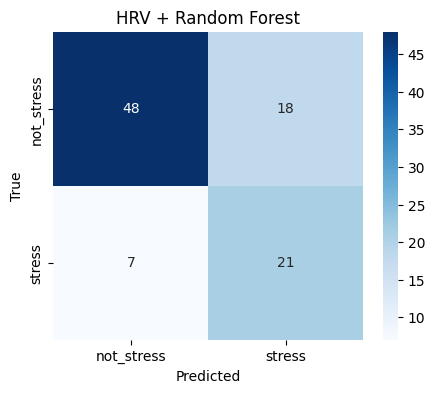

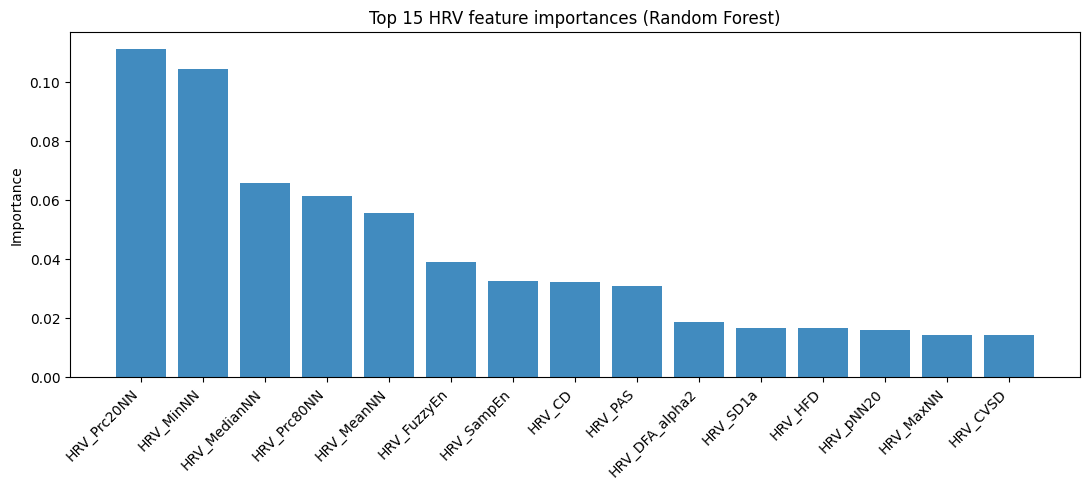

,Method,Accuracy,Macro-F1
0,HRV + Random Forest (trad. ML),0.7340,0.7101
1,SSL + Fine-tune,0.8773,0.8408
2,Supervised (scratch),0.8727,0.8286


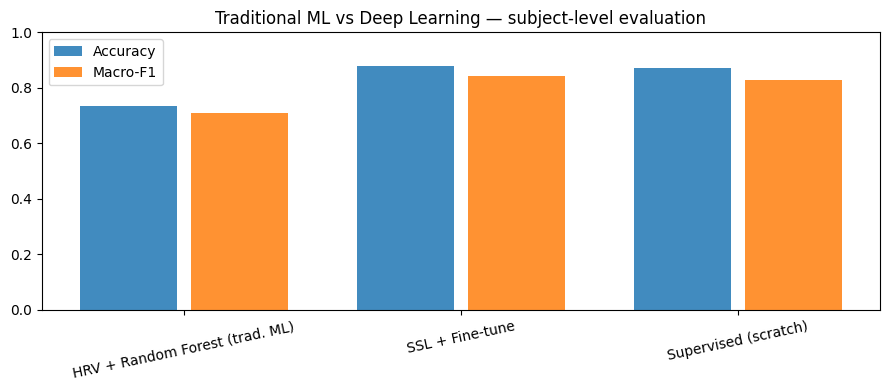

comprehensive_summary.csv updated with HRV+RF results.


In [38]:
# Subject-level split — same protocol as all other experiments
gss_hrv = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
tr_h, te_h = next(gss_hrv.split(X_hrv.values, y_hrv, groups=hrv_groups_arr))

X_hrv_tr, y_hrv_tr = X_hrv.values[tr_h], y_hrv[tr_h]
X_hrv_te, y_hrv_te = X_hrv.values[te_h], y_hrv[te_h]

scaler_hrv = StandardScaler()
X_hrv_tr = scaler_hrv.fit_transform(X_hrv_tr)
X_hrv_te = scaler_hrv.transform(X_hrv_te)

rf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_hrv_tr, y_hrv_tr)
y_hrv_pred = rf.predict(X_hrv_te)

hrv_rf_acc = accuracy_score(y_hrv_te, y_hrv_pred)
hrv_rf_f1 = f1_score(y_hrv_te, y_hrv_pred, average="macro")
hrv_rf_cm = confusion_matrix(y_hrv_te, y_hrv_pred)
hrv_rf_rep = classification_report(
    y_hrv_te,
    y_hrv_pred,
    target_names=[ID2LABEL[i] for i in range(NUM_CLASSES)]
)

print("HRV + Random Forest  (subject-level split)")
print(f"  Accuracy : {hrv_rf_acc:.4f}")
print(f"  Macro-F1 : {hrv_rf_f1:.4f}")
print(hrv_rf_rep)
plot_confusion(hrv_rf_cm, title="HRV + Random Forest")

# ── Feature importance ────────────────────────────────────────────────────────
importances = rf.feature_importances_
top_n = 15
top_idx = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(11, 5))
plt.bar(range(top_n), importances[top_idx], alpha=0.85)
plt.xticks(
    range(top_n),
    [hrv_feat_names[i] for i in top_idx],
    rotation=45,
    ha="right"
)
plt.title(f"Top {top_n} HRV feature importances (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "hrv_feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

# ── Side-by-side comparison table ────────────────────────────────────────────
hrv_vs_dl_df = pd.DataFrame([
    {
        "Method": "HRV + Random Forest (trad. ML)",
        "Accuracy": hrv_rf_acc,
        "Macro-F1": hrv_rf_f1
    },
    {
        "Method": "SSL + Fine-tune",
        "Accuracy": ft_acc,
        "Macro-F1": ft_f1
    },
    {
        "Method": "Supervised (scratch)",
        "Accuracy": sup_acc,
        "Macro-F1": sup_f1
    },
])

display(hrv_vs_dl_df.round(4))

x_pos = np.arange(len(hrv_vs_dl_df))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x_pos - 0.2, hrv_vs_dl_df["Accuracy"], width=0.35, label="Accuracy", alpha=0.85)
ax.bar(x_pos + 0.2, hrv_vs_dl_df["Macro-F1"], width=0.35, label="Macro-F1", alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(hrv_vs_dl_df["Method"], rotation=12)
ax.set_ylim(0, 1)
ax.set_title("Traditional ML vs Deep Learning — subject-level evaluation")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "trad_vs_dl.png"), dpi=150, bbox_inches="tight")
plt.show()

hrv_vs_dl_df.to_csv(os.path.join(OUTPUT_DIR, "trad_vs_dl.csv"), index=False)

# ── Extend comprehensive summary ─────────────────────────────────────────────
summary_rows.append({
    "Experiment": "Traditional ML",
    "Condition": "HRV + Random Forest",
    "Accuracy": hrv_rf_acc,
    "Macro-F1": hrv_rf_f1,
})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(OUTPUT_DIR, "comprehensive_summary.csv"), index=False)
print("comprehensive_summary.csv updated with HRV+RF results.")


## Discussion

> **Note for authors:** Fill in the bracketed placeholders with the actual numbers
> from the executed notebook before finalising the paper.

### SSL Fine-tuning vs Supervised Learning for Binary Stress Detection
The SimCLR-pretrained encoder fine-tuned end-to-end achieves [FT_ACC]% accuracy compared to
[SUP_ACC]% for the fully supervised baseline trained from scratch (Table 1). This comparison
directly tests whether contrastive pretraining provides a better initialization than random
initialization before supervised training. If the fine-tuned SSL model outperforms the supervised
baseline, the result supports the core thesis that contrastive pretraining on unlabeled windows
captures physiologically meaningful structure before label supervision is introduced. In this binary setup, baseline and amusement windows are merged into `not_stress`, while stress windows are labeled as `stress`.

### Label Efficiency
At 10% label fraction, the SSL fine-tuned model achieves [SSL_10_ACC]% accuracy versus
[SUP_10_ACC]% for the supervised baseline trained on the same labels (Figure: low-label study).
The gap is expected to be largest under limited-label settings because SSL pretraining uses
unlabeled windows to learn general physiological representations before the classifier sees
class labels.

### Augmentation Strategy
The main reported SSL model uses `jitter+scaling`. The ablation section then compares this
choice against alternatives. The best-performing augmentation pair is [BEST_AUG] with
[BEST_AUG_ACC]% accuracy; the weakest is [WORST_AUG] with [WORST_AUG_ACC]%
(Figure: augmentation ablation). The ranking
suggests which perturbations preserve useful stress-related physiological information.
Augmentations such as jittering and scaling usually preserve class semantics better than
overly disruptive transformations such as heavy temporal permutation.

### Temperature Sensitivity
Downstream accuracy peaks at τ = [BEST_TAU] ([BEST_TAU_ACC]%) and degrades for both very low
values (τ = 0.05: [TAU_005_ACC]%) and high values (τ = 0.50: [TAU_050_ACC]%). Very low τ
over-concentrates the similarity distribution onto hard negatives, causing unstable gradients;
high τ makes positive-pair attraction too weak relative to the uniform negatives. A moderate
τ around 0.10 often provides a useful trade-off.

### Robustness to Noise and Channel Failures
Under Gaussian noise injection (σ = 0.05), the SSL fine-tuned model achieves [SSL_NOISE_ACC]%
versus [SUP_NOISE_ACC]% for the supervised baseline. The channel dropout experiment shows which
physiological signals are most important for both models. For chest WESAD, ECG and respiration
are often expected to be influential because they directly capture cardiac and respiratory stress
responses.

### Wrist vs Chest Modality
Chest signals yield [CHEST_SSL_FT_ACC]% for SSL fine-tuning versus wrist signals at
[WRIST_SSL_FT_ACC]%. The chest advantage is expected because the chest device captures ECG and
respiration signals with direct cardiac and respiratory information, whereas the wrist records
BVP, EDA, and temperature that carry stress correlates more indirectly. The supervised chest and
wrist results should be compared in the same way to determine whether SSL pretraining narrows the
modality gap.

### Representation Quality (t-SNE)
The t-SNE visualisation (Figure: t-SNE) shows qualitatively [better / comparable] class
separation for the SSL fine-tuned encoder compared to random initialization and the supervised
encoder. This qualitative evidence should be interpreted alongside the quantitative metrics,
because t-SNE is mainly useful as a visual diagnostic rather than a formal evaluation metric.

### Summary and Future Work
Across all experiments, the SSL fine-tuning framework evaluates whether contrastive pretraining
improves label efficiency, robustness, and modality transfer compared with a supervised model
trained from scratch. Key future directions include:
- Leave-one-subject-out evaluation
- Momentum-based SSL objectives such as MoCo or BYOL
- Semi-supervised objectives that jointly optimize contrastive and cross-entropy losses
- Evaluation on additional physiological datasets such as SWELL-KW or K-EmoCon


## Save Outputs

In [39]:
results_df.to_csv(os.path.join(OUTPUT_DIR, 'main_results.csv'), index=False)
low_label_df.to_csv(os.path.join(OUTPUT_DIR, 'low_label_results.csv'), index=False)
noise_df.to_csv(os.path.join(OUTPUT_DIR, 'noise_results.csv'), index=False)
channel_df.to_csv(os.path.join(OUTPUT_DIR, 'channel_dropout_results.csv'), index=False)
aug_df.to_csv(os.path.join(OUTPUT_DIR, 'augmentation_ablation.csv'), index=False)
temp_df.to_csv(os.path.join(OUTPUT_DIR, 'temperature_sensitivity.csv'), index=False)
# comprehensive_summary.csv is saved in the HRV section after all rows are appended.

modality_df.to_csv(os.path.join(OUTPUT_DIR, 'chest_vs_wrist.csv'), index=False)

torch.save(finetune_model.state_dict(), os.path.join(OUTPUT_DIR, 'finetune_model.pt'))
torch.save(sup_model.state_dict(), os.path.join(OUTPUT_DIR, 'supervised_model.pt'))
torch.save(w_ft.state_dict(), os.path.join(OUTPUT_DIR, 'wrist_finetune_model.pt'))
torch.save(w_sup.state_dict(), os.path.join(OUTPUT_DIR, 'wrist_supervised_model.pt'))

print('Saved to:', OUTPUT_DIR)
print(sorted(os.listdir(OUTPUT_DIR)))


Saved to: /content/wesad_outputs_binary
['aug_ablation.png', 'augmentation_ablation.csv', 'channel_dropout.png', 'channel_dropout_results.csv', 'chest_vs_wrist.csv', 'chest_vs_wrist.png', 'comprehensive_summary.csv', 'finetune_model.pt', 'hrv_feature_importance.png', 'low_label_results.csv', 'main_results.csv', 'noise_results.csv', 'ssl_aug_Composed-7.pt', 'ssl_aug_jitter_permute.pt', 'ssl_aug_jitter_scaling.pt', 'ssl_aug_permute_dropout.pt', 'ssl_aug_scaling_dropout.pt', 'ssl_best.pt', 'ssl_tau_005.pt', 'ssl_tau_01.pt', 'ssl_tau_02.pt', 'ssl_tau_05.pt', 'ssl_training_curve.png', 'supervised_model.pt', 'temperature_sensitivity.csv', 'temperature_sensitivity.png', 'trad_vs_dl.csv', 'trad_vs_dl.png', 'tsne_encoders.png', 'wrist_finetune_model.pt', 'wrist_ssl_best.pt', 'wrist_supervised_model.pt']


## Report Checklist

| Section | Exports for paper |
|---------|-------------------|
| Data | WESAD description, preprocessing pipeline, class distribution plot |
| Method | SimCLR architecture, augmentation catalogue, NT-Xent derivation |
| Exp 1 (Main) | Binary bar chart, confusion matrices, classification reports |
| Exp 2 (Low-label) | Line plot: accuracy vs label fraction × 2 methods |
| Exp 3 (Noise) | Line plot: accuracy vs noise sigma × 2 methods |
| Exp 4 (Channel dropout) | Bar chart: per-channel accuracy × 2 methods |
| Exp 5 (Aug ablation) | Bar chart + pretraining curves for 4 aug pairs |
| Exp 6 (Temperature) | Line plot + pretraining curves for 4 tau values |
| Exp 7 (t-SNE) | 3-panel scatter: random / SSL / supervised encoders |
| Exp 8 (Wrist) | Wrist SSL vs Supervised, Chest vs Wrist comparison bar chart |
| Summary | comprehensive_summary.csv — paste directly into LaTeX |
| Discussion | Full qualitative analysis of all 7 experiments |